<a href="https://colab.research.google.com/github/e-mo-ali/NLP_Homework/blob/main/punctuation_ARABIC_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import output
output.disable_custom_widget_manager()

In [ ]:
!wget "https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded"

--2025-12-17 11:45:22--  https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/24436cd0-7900-4c94-8535-80d27820f8ee [following]
--2025-12-17 11:45:22--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/24436cd0-7900-4c94-8535-80d27820f8ee
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.72.88, 3.5.71.132, 52.92.35.218, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.72.88|:443... conn

In [ ]:
!unzip file_downloaded -d dataset


Archive:  file_downloaded
   creating: dataset/SSAC-UNPC/
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_1.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_10.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_11.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_12.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_13.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_14.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_15.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_16.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_17.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_18.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_19.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_2.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_20.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_21.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_22.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_23.txt  
  inflating: dataset/SSAC-UNPC/UNPC_Sentences_24.txt  
  inflati

In [ ]:
import os
import re
import pandas as pd
import numpy as np

In [ ]:
folder = "dataset/SSAC-UNPC"
doc = []
for file in os.listdir(folder):
    file_path = os.path.join(folder, file)
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
        doc.append(lines)
    # for i in range(10):
    #   print(lines[i],'\n')
    # print('\n')

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/SSAC-UNPC'

In [ ]:
print('Number of documents:',len(doc),'\n','Number of phrase in one document: ',len(lines))

Number of documents: 79 
 Number of phrase in one document:  150000




>  # To convert the Input text to output sequence word and the punks come after each word

In [ ]:
def encoding_word(texts):
  words_without_puncts = []
  leabels = []
  l_id=[]
  punct = {'.':1,'،':2,'؟':3,'!':4,':':5,'؛':6,' ':0}
  # for text in texts:
  words = texts.split()
  for word in words:
    match = re.match(r"(.*?)([،\.\؟\!\:\؛])?$", word)
    clean = match.group(1)
    puncts_in_phrase = match.group(2) or " "
    words_without_puncts.append(clean)
    leabels.append(puncts_in_phrase)
    # print(leabels)
  l_id=[punct[p] for p in leabels]
  df = pd.DataFrame({
  "word": words_without_puncts,
  "punct": leabels,
  "label_id": l_id
  })
  return df

**Create a CSV file for the dataset after sequential the data**

In [ ]:
def process(line):
  filename = "dataset.csv"
  if not os.path.exists(filename):
      line.to_csv(filename, index=False, encoding="utf-8")
  else:
      line.to_csv(filename, index=False, encoding="utf-8", header=False, mode="a")
  # print(df.path)

لتسهيل التعامل مع البيانات تم تحويلها إلى ملف csv

In [ ]:
import os
folder = "dataset/SSAC-UNPC"
doc = []
batch_size = 50000
batch = []
# df=pd.DataFrame()
for file in os.listdir(folder):
    file_path = os.path.join(folder, file)
    with open(file_path, "r", encoding="utf-8") as f:
        # lines = f.readlines()
        for line in f:
          # print(line)
          # break
          ds =encoding_word(line)
          batch.append(ds)
          if len(batch) >= batch_size:
            pd_batch = pd.concat(batch)
            process(pd_batch)
            batch = []

          # process(ds)
        # doc.append(lines)
    # for i in range(10):
    #   print(lines[i],'\n')
    # print('\n')

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp dataset.csv /content/drive/MyDrive/F_dataset


#**CODE START HERE**

In [ ]:
!pip install -qq gdown

**Get some data from the dataset as chunks to prevent Colab crush and saving time**

In [ ]:
import pandas as pd
import gdown
# https://drive.google.com/file/d/1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6/view?usp=sharing
url = "https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6"

temp_path = "/tmp/dataset.csv"

gdown.download(url, temp_path, quiet=False)

chunks = pd.read_csv(temp_path, chunksize=200000)

# for chunk in chunks:
#     print(chunk.sample(10))# || PRINT SOME SAMPLES ||
#     break


Downloading...
From (original): https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6
From (redirected): https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6&confirm=t&uuid=596208a4-7339-4f5a-b5e2-32e48ea315f7
To: /tmp/dataset.csv
100%|██████████| 4.68G/4.68G [01:18<00:00, 59.8MB/s]


بدلاً من استخدام كامل الداتا استخدمنا جزء منها حتى نتمكن من التعامل مع محدودية colab


In [ ]:
for chunk in chunks:
    print(chunk.sample(20))# || PRINT SOME SAMPLES ||
    break


             word punct  label_id
22298     البلدان     .         1
105782        طرد               0
153630   للمشاريع     ،         2
140272        ٢٤(               0
166884     البالغ               0
189869     المقرر               0
88907        تدخل               0
47797       للحظر     .         1
51681       حكومة               0
19146         قوة               0
129076     الاولى     ،         2
112433    عنصريين     .         1
122090  الاعلانات     ،         2
143195        بان               0
161152        بيت               0
130277     بمسالة               0
98389      انفسهم               0
98707          في               0
15941     للناجين               0
197464     الجنسي               0


In [ ]:
X = chunk["word"].tolist()
Y = chunk["label_id"].tolist()
for i in range(100):
  if(Y[i] == 4):
    continue
  print('X labels: ',X[i],'\n','Y labels: ',Y[i],'\n')


X labels:  ولهذا 
 Y labels:  0 

X labels:  السبب 
 Y labels:  0 

X labels:  قررت 
 Y labels:  0 

X labels:  الحكومة 
 Y labels:  0 

X labels:  التماس 
 Y labels:  0 

X labels:  التمويل 
 Y labels:  0 

X labels:  للصندوق 
 Y labels:  0 

X labels:  من 
 Y labels:  0 

X labels:  مصادر 
 Y labels:  0 

X labels:  خاصة 
 Y labels:  1 

X labels:  وخصصت 
 Y labels:  0 

X labels:  الحكومة 
 Y labels:  0 

X labels:  نفسها 
 Y labels:  0 

X labels:  ٠٠٥ 
 Y labels:  0 

X labels:  مليون 
 Y labels:  0 

X labels:  ين 
 Y labels:  0 

X labels:  )نحو 
 Y labels:  0 

X labels:  ٧,٥ 
 Y labels:  0 

X labels:  مليون 
 Y labels:  0 

X labels:  دولار 
 Y labels:  0 

X labels:  من 
 Y labels:  0 

X labels:  دولارات 
 Y labels:  0 

X labels:  الولايات 
 Y labels:  0 

X labels:  المتحدة( 
 Y labels:  0 

X labels:  لتغطية 
 Y labels:  0 

X labels:  التكاليف 
 Y labels:  0 

X labels:  الادارية 
 Y labels:  0 

X labels:  للصندوق 
 Y labels:  0 

X labels:  وكذلك 
 Y labels:  0 

X la

sequence the words to phrase as any phrase end with one of ( '.' , '؟' , '!' )

In [ ]:
def sequence(words,labels):
  X=[]
  Y=[]
  phrase = []
  phrase_labels = []
  # punct = {'.':1,'،':2,'؟':3,'!':4,':':5,'؛':6,' ':0}

  for word , label in zip(words , labels):
    phrase.append(word)
    phrase_labels.append(label)
    if label in [1,3,4]: # . or ؟ or !
      X.append(phrase)
      Y.append(phrase_labels)
      phrase=[]
      phrase_labels=[]
  if len(phrase)>0:
    X.append(phrase)
    Y.append(phrase_labels)

  return X,Y


In [ ]:
X , Y = sequence(X,Y)

In [ ]:
for i in range (3):
  print(X[i],'\n',Y[i],'\n')

['ولهذا', 'السبب', 'قررت', 'الحكومة', 'التماس', 'التمويل', 'للصندوق', 'من', 'مصادر', 'خاصة'] 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1] 

['وخصصت', 'الحكومة', 'نفسها', '٠٠٥', 'مليون', 'ين', ')نحو', '٧,٥', 'مليون', 'دولار', 'من', 'دولارات', 'الولايات', 'المتحدة(', 'لتغطية', 'التكاليف', 'الادارية', 'للصندوق', 'وكذلك', 'لتمويل', 'برامج', 'الرعاية', 'الطبية', 'والاجتماعية', 'للضحايا', 'من', 'النساء', 'على', 'النحو', 'المشار', 'اليه', 'اعلاه'] 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1] 

['٣٣١', '-', 'وقد', 'تلقت', 'المقررة', 'الخاصة', 'منذ', 'الزيارة', 'التي', 'قامت', 'بها', 'الى', 'اليابان', 'معلومات', 'اضافية', 'من', 'حكومة', 'اليابان', 'مفادها', 'انه', 'قد', 'تم', 'حتى', 'وقت', 'كتابة', 'التقرير', 'تلقي', 'تبرعات', 'بلغت', 'في', 'مجموعها', 'مليون', 'دولار', 'معظمها', 'تبرعات', 'من', 'افراد'] 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1] 



**First i need to remove the < nan > samples to prevent errors while creating embedding**

In [ ]:
clean_X = []
clean_Y = []

for sent, labels in zip(X, Y):
    if isinstance(sent, list):
        new_sent = []
        new_labels = []
        for w, l in zip(sent, labels):
            if isinstance(w, str) and w.strip() != "":
                new_sent.append(w)
                new_labels.append(l)

        if len(new_sent) > 0:
            clean_X.append(new_sent)
            clean_Y.append(new_labels)
print("deleting samples: " ,len(X)-len(clean_X))
X = clean_X
Y = clean_Y

deleting samples:  0


في بعض الحالات كان ضمن البيانات قيم NaN وتسببت في عرقلة التدريب وإنشاء embedding لهذا قمنا بحذف كل قيم NaN مع label لها


In [ ]:
!pip install tensorflow

**Tokeniz the words using keras tokenizer**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(X)


**transform text to sequence number**

In [ ]:
X_seq_num = tokenizer.texts_to_sequences(X)

In [ ]:
X_seq_num[1]

[9328,
 31,
 665,
 1104,
 1147,
 14038,
 7110,
 14039,
 1147,
 1399,
 3,
 1753,
 313,
 3378,
 7111,
 7112,
 1048,
 7109,
 218,
 9329,
 571,
 1558,
 1011,
 490,
 2378,
 3,
 87,
 4,
 766,
 829,
 379,
 439]

**Padding to max length of the phrases**

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(len(s) for s in X_seq_num)

X_padded = pad_sequences(X_seq_num, maxlen=max_len, padding="post")
Y_padded = pad_sequences(Y, maxlen=max_len, padding="post")


# To start traning we need to decide whitch model is work for our problem
**First will be LSTM**

It understand the Chronological order of words
and desgine for the sequence problem

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test, Y_train ,Y_test = train_test_split(X_padded,Y_padded,test_size = 0.2)

In [ ]:
print(X_train[0])
print(X_test[0])
print(Y_train[0])
print(Y_test[0])

[ 230    6 3446 ...    0    0    0]
[224   2  72 ...   0   0   0]
[0 0 0 ... 0 0 0]
[0 0 2 ... 0 0 0]


**To ignor the zeros in the padded data while compute the accuracy**

In [ ]:
import tensorflow as tf
def masked_accuracy(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int64)
    y_true = tf.cast(y_true, tf.int64)

    mask = tf.not_equal(y_true, 0)
    matches = tf.equal(y_true, y_pred)
    matches = tf.logical_and(mask, matches)

    return tf.reduce_sum(tf.cast(matches, tf.float32)) / tf.reduce_sum(tf.cast(mask, tf.float32))





# 1. prepare LSTM model




In [ ]:
MAX_LEN = max(len(s) for s in X_train)
Classes = 7
voc_size = len(tokenizer.word_index)+1


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(MAX_LEN,))
x = Embedding(
    input_dim=voc_size,
    output_dim=128,
    mask_zero=True,
    trainable=True
)(inputs)

x = LSTM(128, return_sequences=True)(x)

outputs = TimeDistributed(
    Dense(Classes, activation="softmax")
)(x)

model_lstm = Model(inputs, outputs)

model_lstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[masked_accuracy]
)

model_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 393)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 393, 128)  │  4,046,592 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 393)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 393, 128)  │    131,584 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 393, 7)    │        903 │ lstm[0][0],       │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,179,079 (15.94 MB)

 Trainable params: 4,179,079 (15.94 MB)

 Non-trainable params: 0 (0.00 B)

**Train the Model**

In [ ]:
history_lstm = model_lstm.fit(
    X_train,
    Y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.3675 - masked_accuracy: 7.2655e-04 - val_loss: 0.3295 - val_masked_accuracy: 0.0110
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.2826 - masked_accuracy: 0.0440 - val_loss: 0.3339 - val_masked_accuracy: 0.0394
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.2451 - masked_accuracy: 0.1303 - val_loss: 0.3370 - val_masked_accuracy: 0.0877
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - loss: 0.2293 - masked_accuracy: 0.2113 - val_loss: 0.3409 - val_masked_accuracy: 0.0775
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.2124 - masked_accuracy: 0.2495 - val_loss: 0.3522 - val_masked_accuracy: 0.1102
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.1851 - masked_accuracy: 0.3577 - val_loss: 0.3594 - val_masked_accuracy: 0.0988
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.1534 - masked_accuracy: 0.5144 - val_loss: 0.3914 - val_masked_accuracy: 0.

**Function to plot the model history**

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history.get('val_loss', []), label='val')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    if 'masked_accuracy' in history.history:
        metric = 'masked_accuracy'
        val_metric = 'val_masked_accuracy'
    else:
        metric = 'accuracy'
        val_metric = 'val_accuracy'

    plt.plot(history.history[metric], label='train')
    plt.plot(history.history.get(val_metric, []), label='val')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)

    plt.show()


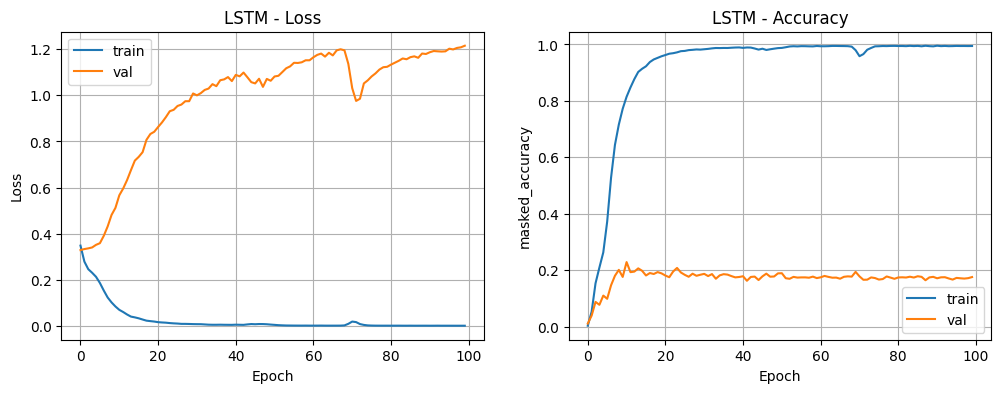

In [ ]:
plot_history(history_lstm,'LSTM')

لوحظ أثناء التدريب أن دقة التدريب كانت مرتفعة جدًا (98%) بينما كانت دقة التحقق منخفضة (17%)، مما يشير إلى مشكلة overfitting. هذا يعني أن النموذج تعلم بيانات التدريب بشكل ممتاز ولكنه لم يتمكن من التعميم على بيانات جديدة. الفارق الكبير بين train loss المنخفض وvalidation loss المرتفع يعكس أن النموذج يحفظ تفاصيل التدريب ولا يتعلم الأنماط العامة

In [ ]:
y_pred = model_lstm.predict(X_test)


49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step


In [ ]:
import numpy as np
y_pred_labels = np.argmax(y_pred, axis=-1)

y_true_flat = []
y_pred_flat = []

for true_seq, pred_seq in zip(Y_test, y_pred_labels):
    for t, p in zip(true_seq, pred_seq):
        if t != 0:      # تجاهل padding
            y_true_flat.append(t)
            y_pred_flat.append(p)

In [ ]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=[1,2,3,4,5,6],
    digits=4
))

macro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average="macro"
)

micro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average="micro"
)

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)


              precision    recall  f1-score   support

           1     0.6317    0.1756    0.2748      1543
           2     0.7000    0.1817    0.2885      1811
           3     0.0000    0.0000    0.0000         3
           4     0.0000    0.0000    0.0000         0
           5     0.5000    0.0426    0.0784        47
           6     0.1181    0.2113    0.1515        71

   micro avg     0.5990    0.1776    0.2739      3475
   macro avg     0.3250    0.1019    0.1322      3475
weighted avg     0.6545    0.1776    0.2765      3475

Macro F1: 0.13221072725973873
Micro F1: 0.17755395683453237


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

حدثت مشكلة Overfitting في النموذج بسبب عدم توازن البيانات بين الفئات، إضافةً إلى أن نموذج LSTM أحادي الاتجاه يعتمد فقط على السياق السابق للكلمة ولا يأخذ السياق اللاحق بعين الاعتبار، وهو ما يجعله غير مناسب بشكل كافٍ لطبيعة هذه المشكلة اللغوية، مما أدى إلى ضعف التعميم على بيانات الاختبار.





In [ ]:
model_lstm.save("/content/drive/MyDrive/models/lstm_punct.h5")


In [ ]:
model_lstm.evaluate(X_test,Y_test)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.2037 - masked_accuracy: 0.1804


[1.2162227630615234, 0.1769193857908249]



---



# 2.   Now using BiLSTM





شرح نموذج BiLSTM:

 يقوم بمعالجة التسلسل النصي في اتجاهين: من البداية إلى النهاية (Forward)
  ومن النهاية إلى البداية (Backward).
   هذا يسمح للنموذج بفهم السياق السابق واللاحق لكل كلمة داخل الجملة

In [ ]:
from tensorflow.keras.layers import Bidirectional
inputs = Input(shape=(MAX_LEN,))
x = Embedding(
    input_dim=voc_size,
    output_dim=128,
    mask_zero=True,
    trainable=True
)(inputs)

x = Bidirectional(
    LSTM(128, return_sequences=True)
)(x)

outputs = TimeDistributed(
    Dense(Classes, activation="softmax")
)(x)

model_bilstm = Model(inputs, outputs)

model_bilstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[masked_accuracy]
)

model_bilstm.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 393)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 393, 128)  │  4,046,592 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 393)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 393, 256)  │    263,168 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 393, 7)    │      1,799 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,311,559 (16.45 MB)

 Trainable params: 4,311,559 (16.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = model_bilstm.fit( X_train,
    Y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 34s 221ms/step - loss: 0.9179 - masked_accuracy: 0.0253 - val_loss: 0.2626 - val_masked_accuracy: 0.3262
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - loss: 0.2524 - masked_accuracy: 0.3335 - val_loss: 0.2339 - val_masked_accuracy: 0.4284
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - loss: 0.1888 - masked_accuracy: 0.4340 - val_loss: 0.2203 - val_masked_accuracy: 0.4528
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - loss: 0.1491 - masked_accuracy: 0.5480 - val_loss: 0.2216 - val_masked_accuracy: 0.4641
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - loss: 0.1231 - masked_accuracy: 0.6162 - val_loss: 0.2241 - val_masked_accuracy: 0.5597
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - loss: 0.0949 - masked_accuracy: 0.7147 - val_loss: 0.2279 - val_masked_accuracy: 0.6006
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - loss: 0.0759 - masked_accuracy: 0.7939 - val_loss: 0.2376 - val_masked_accuracy:

**Plot History**

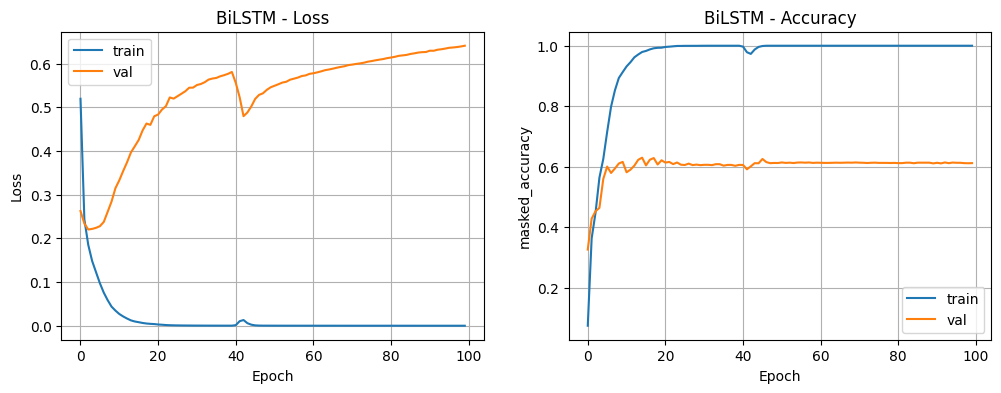

In [ ]:
plot_history(history_bilstm, "BiLSTM")


we get some improve by using BiLSTM that because it foucs on the before and after the word

but still the probelm of unbalanced data is on

لوحظ تحسن واضح في أداء التدريب عند استخدام BiLSTM مقارنةً بـ LSTM، ويعود ذلك إلى قدرة BiLSTM على استيعاب معلومات سياقية أشمل. في نموذج LSTM التقليدي، يتم تفسير الكلمة اعتمادًا فقط على الكلمات السابقة، مما قد يؤدي إلى فقدان معلومات مهمة تأتي لاحقًا في الجملة

In [ ]:
model_bilstm.save("/content/drive/MyDrive/models/bilstm_punct.h5")


In [ ]:
y_pred = model_bilstm.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=-1)

y_true_flat = []
y_pred_flat = []

for true_seq, pred_seq in zip(Y_test, y_pred_labels):
    for t, p in zip(true_seq, pred_seq):
        if t != 0:
            y_true_flat.append(t)
            y_pred_flat.append(p)

from sklearn.metrics import classification_report, f1_score

print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=[1,2,3,4,5,6],
    digits=4
))

macro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average="macro"
)

micro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average="micro"
)

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)


49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step
              precision    recall  f1-score   support

           1     0.9915    0.9857    0.9886      1543
           2     0.9455    0.3065    0.4629      1811
           3     0.0000    0.0000    0.0000         3
           4     0.0000    0.0000    0.0000         0
           5     0.3333    0.0213    0.0400        47
           6     0.1923    0.0704    0.1031        71

   micro avg     0.9684    0.5991    0.7403      3475
   macro avg     0.4104    0.2307    0.2658      3475
weighted avg     0.9414    0.5991    0.6829      3475

Macro F1: 0.26576730099802354
Micro F1: 0.599136690647482


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
model_bilstm.evaluate(X_test,Y_test)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5924 - masked_accuracy: 0.6228


[0.6184310913085938, 0.6049128770828247]

أظهرت النتائج أن نموذج BiLSTM يتفوق على نموذج LSTM في مهمة استعادة علامات الترقيم، وذلك بسبب قدرة BiLSTM على الاستفادة من السياق السابق واللاحق للكلمة في آنٍ واحد. وقد لوحظ تحسن ملحوظ في كل من Micro-F1 والدقة المقنّعة (Masked Accuracy)، في حين ظل Macro-F1 منخفضًا نسبيًا نتيجة عدم توازن البيانات وندرة بعض فئات علامات الترقيم.

# LET'S COMPARE

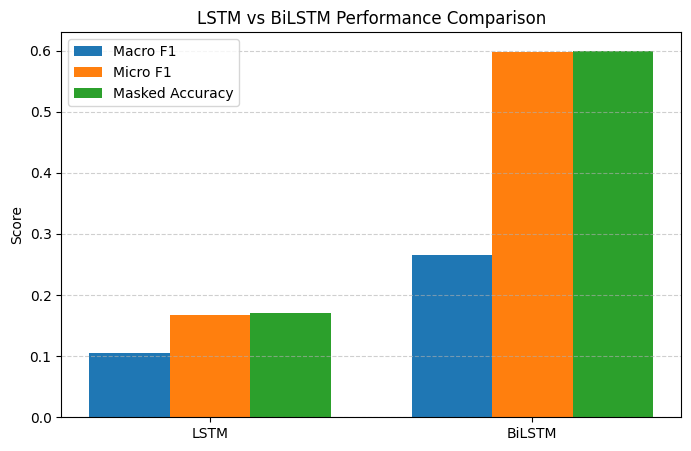

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ["LSTM", "BiLSTM"]

macro_f1 = [0.106, 0.266]
micro_f1 = [0.167, 0.598]
masked_acc = [0.17, 0.60]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, macro_f1, width, label="Macro F1")
plt.bar(x, micro_f1, width, label="Micro F1")
plt.bar(x + width, masked_acc, width, label="Masked Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("LSTM vs BiLSTM Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


النتائج توضح تحسن عند استخدام BiLSTM من LSTM لكنه لازال غير كافاً للمشكلة



---





> # **تعاني مجموعة البيانات من عدم توازن بين الفئات، لذلك تم استخدام أوزان للفئات داخل دالة الخسارة (Weighted Loss) بهدف زيادة قيمة الخسارة عند الخطأ في تصنيف الفئات النادرة، مثل علامة الاستفهام (؟). يساعد ذلك النموذج على إعطاء اهتمام أكبر للفئات قليلة الظهور أثناء التدريب، مما يؤدي إلى تحسين أداء النموذج وقدرته على التعميم.**






أختيار الأوزان تم بكم مرة تكررت هذه الإشارة في البيانات وما مدى أهميتها ضمن النص

In [ ]:
import tensorflow as tf

class_weights = tf.constant([
    0.1,  # PAD
    1.0,  # .
    1.5,  # ،
    2.0,  # ؟
    2.0,  # !
    3.0,  # :
    3.0   # ؛
])

def weighted_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true, y_pred
    )
    weights = tf.gather(class_weights, y_true)
    loss = loss * tf.cast(weights, tf.float32)
    return tf.reduce_sum(loss) / tf.reduce_sum(weights)


In [ ]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
inputs = Input(shape=(MAX_LEN,))
x = Embedding(
    input_dim=voc_size,
    output_dim=128,
    mask_zero=True,
    trainable=True
)(inputs)

x = Bidirectional(
    LSTM(128, return_sequences=True)
)(x)

outputs = TimeDistributed(
    Dense(Classes, activation="softmax")
)(x)

model_bilstm_weights = Model(inputs, outputs)

model_bilstm_weights.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=weighted_loss,
    metrics=[masked_accuracy]
)
early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
model_bilstm_weights.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 393)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 393, 128)  │  4,046,592 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 393)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 393, 256)  │    263,168 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 393, 7)    │      1,799 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,311,559 (16.45 MB)

 Trainable params: 4,311,559 (16.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm_weights = model_bilstm_weights.fit( X_train,
    Y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.2,
    callbacks=[early]
)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 647s 8s/step - loss: 1.1215 - masked_accuracy: 0.6931 - val_loss: 0.3714 - val_masked_accuracy: 0.9524
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 605s 7s/step - loss: 0.3796 - masked_accuracy: 0.9370 - val_loss: 0.2951 - val_masked_accuracy: 0.9559
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 630s 8s/step - loss: 0.2230 - masked_accuracy: 0.9534 - val_loss: 0.3169 - val_masked_accuracy: 0.9555
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 592s 8s/step - loss: 0.1014 - masked_accuracy: 0.9790 - val_loss: 0.3518 - val_masked_accuracy: 0.9296
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 589s 8s/step - loss: 0.0550 - masked_accuracy: 0.9895 - val_loss: 0.3659 - val_masked_accuracy: 0.9481


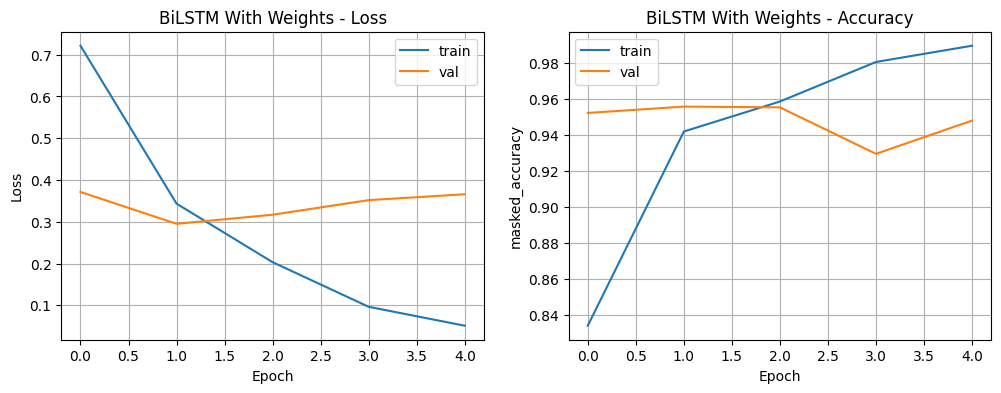

In [ ]:
plot_history(history_bilstm_weights, "BiLSTM With Weights")


بهذه الطريقة تمكنا من منع overfitting وتمكنا من تحسين النموذج بشكل كبير

In [ ]:
model_bilstm_weights.save("/content/drive/MyDrive/models/bilstm_weights_punct_tf.keras")


In [ ]:
import numpy as np
y_pred = model_bilstm_weights.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=-1)

y_true_flat = []
y_pred_flat = []

for true_seq, pred_seq in zip(Y_test, y_pred_labels):
    for t, p in zip(true_seq, pred_seq):
        if t != 0:
            y_true_flat.append(t)
            y_pred_flat.append(p)

from sklearn.metrics import classification_report, f1_score

print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=[1,2,3,4,5,6],
    digits=4
))

macro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average="macro"
)

micro_f1 = f1_score(
    y_true_flat,
    y_pred_flat,
    average="micro"
)

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)


49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 399ms/step
              precision    recall  f1-score   support

           1     0.9735    0.9780    0.9758      1543
           2     0.9229    0.9805    0.9508      1746
           3     0.0000    0.0000    0.0000         3
           4     0.0000    0.0000    0.0000         0
           5     0.0000    0.0000    0.0000        44
           6     0.0000    0.0000    0.0000        69

    accuracy                         0.9460      3405
   macro avg     0.3161    0.3264    0.3211      3405
weighted avg     0.9144    0.9460    0.9297      3405

Macro F1: 0.38531973686585064
Micro F1: 0.9459618208516887


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
model_bilstm_weights.evaluate(X_test,Y_test)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3154 - masked_accuracy: 0.9510


[0.3312227427959442, 0.9448443651199341]

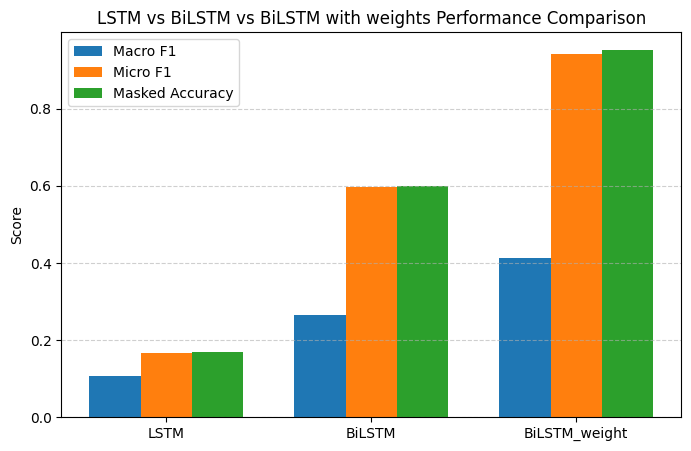

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ["LSTM", "BiLSTM","BiLSTM_weight"]

macro_f1 = [0.106, 0.266,0.412]
micro_f1 = [0.167, 0.598,0.943]
masked_acc = [0.17, 0.60,0.9510]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, macro_f1, width, label="Macro F1")
plt.bar(x, micro_f1, width, label="Micro F1")
plt.bar(x + width, masked_acc, width, label="Masked Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("LSTM vs BiLSTM vs BiLSTM with weights Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


عند دمج Weighted Loss مع نموذج BiLSTM، تحسن أداء النموذج بشكل أكبر، خاصة في حالة عدم توازن البيانات بين الفئات (Class Imbalance). تعمل الـ Weighted Loss على إعطاء وزن أكبر للفئات النادرة أثناء التدريب، مما يمنع النموذج من الانحياز للفئات الأكثر تكرارًا. هذا أدى إلى تعلم أكثر عدالة لجميع الفئات وتحسن ملحوظ في مقاييس التقييم مثل F-score مقارنة باستخدام BiLSTM بدون أوزان أو باستخدام LSTM التقليدي

that's clearly shows the benfits of wieghted loss in unbalanced stuation



---





> # It's clear that the BiLSTM with weighted loss is the Best Model



**Let's create a dictionary for it**

In [ ]:
macro_f1 = [0.106, 0.266,0.412]
micro_f1 = [0.167, 0.598,0.943]
masked_acc = [0.17, 0.60,0.9510]
lstm = {
    "number_step": 1,
    "name_model": "LSTM",
    "features": "Word embeddings",
    "parameters_model": "default",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.17,
    "F-score-macro": 0.106,
    "F-score-micro": 0.167
}
Bilstm = {
    "number_step": 1,
    "name_model": "BiLSTM",
    "features": "Word embeddings",
    "parameters_model": "default",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.60,
    "F-score-macro": 0.266,
    "F-score-micro": 0.598
}
bilstm_WL = {
    "number_step": 3,
    "name_model": "BiLSTM_weight",
    "features": "Word embeddings",
    "parameters_model": "class weights",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.9510,
    "F-score-macro": 0.412,
    "F-score-micro": 0.943
}
dictionary = []
dictionary.append(lstm)
dictionary.append(Bilstm)
dictionary.append(bilstm_WL)



> # Pretrained Embeddings



In [ ]:
!pip install -qq gensim

helper functions

مجموعة توابع مساعدة بالتعامل مع البيانات
1 clean_chunk :
يقوم باخذ الكلمات ويعالجها بحيث تصبح اكثر ملائمة لموديل التضمين المدرب مسبقا بحيث يضمن توليد متجهات لمعظم الكلمات
فكلمة مثل "هدية" او "٥٠٠ مليون" ليس لها متجه مقابل لها بينما "هديه" و "500 مليون" يوجد لها
2 chunk_to_sentences:
  max_lenght يجمع الكلمات ضمن جمل لا يتجاوز طولها ال
  ('.','?','!')حيث يقسم الجمل حسب علامات الترقيم التي تظهر في نهاية الجملة

3 word2vec:
يعيد قيمة المتجه المقابل لكل كلمة حسب موديل الضمين المستخدم

4 sentence_to_vec:
يمر على كافة الكلمات في الجملة ويحولها لمتجهات

5 pad_batch:
labelيضيف حشو للكلمات وال
لتصبح كلها بنفس الطول

6 train_chunk:
ياخذ مجموعة بيانات وموديل التضمين المدرب مسبقا والشبكة
يعالج البيانات ويقسمها الى جمل ويحول كل كلمة فيها لمتجه ليهيئها للدخول للشبكة
يخلق وزن لكل label
ثم يبداء التدريب

7 test_chunk:
اخذ مجموعة بيانات وموديل التضمين المدرب مسبقا والشبكة
يعالج البيانات ويقسمها الى جمل ويحول كل كلمة فيها لمتجه ليهيئها للدخول للشبكة
ثم يتحقق منها على الشبكة المدربة

8 build_sample_weights:
يخلق وزن معين لكل label
يساعد بتدريب الشبكة بحيث لا يبدي اهمية للحشو وللفراغات كما لباقي علامات الترقيم


In [ ]:
PAD_LABEL = 7
END_LABELS = {1, 3, 4}
UNK_VECTOR = np.random.normal(
    scale=0.1,
    size=(300,)
).astype(np.float32)

arabic_to_eng = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")

#تنظيف الكلمات وتهيئتها للاستخدام ضمن موديل التضمين المدرب مسبقا
def clean_chunk(df):

    s = df["word"].astype(str)

    s = s.str.strip()

    s = s.str.replace(r"[أإآ]", "ا", regex=True)
    s = s.str.replace("ة", "ه")
    s = s.str.replace("ى", "ي")
    s = s.str.replace(r"[()]", "", regex=True)


    s = s.str.translate(arabic_to_eng)

    df["word"] = s
    return df


# تجميع الكلمات ضمن جمل اما حسب نهاية الجملة او حسب طول الجمل اذا تم تحديده
def chunk_to_sentences(df, end_labels = END_LABELS, max_lenght=100):
    sentences = []
    sentence_labels = []

    current_words = []
    current_labels = []

    for word, label in zip(df["word"], df["label_id"]):
        current_words.append(word)
        current_labels.append(label)

        if max_lenght:
          if label in end_labels or len(current_words)>= max_lenght:
              sentences.append(current_words)
              sentence_labels.append(current_labels)

              current_words = []
              current_labels = []
        else:
          if label in end_labels:
              sentences.append(current_words)
              sentence_labels.append(current_labels)

              current_words = []
              current_labels = []

    if current_words:
        sentences.append(current_words)
        sentence_labels.append(current_labels)

    return sentences, sentence_labels

# تحويل كلمة لمتجه
def word2vec(word, model):
    if word in model.wv:
      return model.wv[word]
    return UNK_VECTOR

# تحويل كلمات جملة لمتجه
def sentence_to_vec(sentence, model):
    return np.array(
        [word2vec(w, model) for w in sentence],
        dtype=np.float32
    )


def pad_batch(X, y, pad_label):
    X_pad = tf.keras.preprocessing.sequence.pad_sequences(
        X,
        padding="post",
        dtype="float32"
    )

    y_pad = tf.keras.preprocessing.sequence.pad_sequences(
        y,
        padding="post",
        value=pad_label
    )

    return X_pad, y_pad

#تدريب الشبكة على قسم من البيانات
def train_chunk(chunk,em_model,model):
  chunk = clean_chunk(chunk)
  sentences, labels = chunk_to_sentences(chunk)
  sentences = [sentence_to_vec(s, em_model) for s in sentences]
  sentences, labels = pad_batch(sentences, labels, PAD_LABEL)

  sample_weights = build_sample_weights(labels, label_weights)

  model.fit(
        sentences, #X_pad
        labels, #y_pad
        epochs=3,
        sample_weight=sample_weights,
        batch_size=16,
        validation_split=0.2
    )

def test_chunk(chunk,em_model,model):
    chunk = clean_chunk(chunk)
    sentences, labels = chunk_to_sentences(chunk)
    sentences = [sentence_to_vec(s, em_model) for s in sentences]
    sentences, labels = pad_batch(sentences, labels, PAD_LABEL)

    # تقييم
    return model.evaluate(
        sentences, #X_pad
        labels, #y_pad
        verbose=0
    )


label_weights = {
    0: 0.2,   # لا ترقيم (الأكثر شيوعًا)
    1: 2.0,   # .
    2: 2.0,   # ,
    3: 2.5,
    4: 2.5,
    5: 2.5,
    6: 2.5,
    7: 2.5,
    PAD_LABEL: 0.0
}

def build_sample_weights(y, label_weights):

    weights = np.zeros_like(y, dtype=np.float32)

    for label, w in label_weights.items():
        weights[y == label] = w

    return weights


In [ ]:
import tensorflow as tf
def masked_accuracy(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int64)
    y_true = tf.cast(y_true, tf.int64)

    mask = tf.not_equal(y_true, PAD_LABEL)

    matches = tf.equal(y_true, y_pred)
    matches = tf.logical_and(mask, matches)

    return tf.reduce_sum(tf.cast(matches, tf.float32)) / (
        tf.reduce_sum(tf.cast(mask, tf.float32)) + 1e-9
    )

def masked_f1_micro(y_true, y_pred):
    # توقعات النموذج
    y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int64)
    y_true = tf.cast(y_true, tf.int64)

    # تجاهل padding
    mask = tf.not_equal(y_true, PAD_LABEL)

    y_true = tf.boolean_mask(y_true, mask)
    y_pred = tf.boolean_mask(y_pred, mask)

    # True Positives
    tp = tf.reduce_sum(
        tf.cast(tf.equal(y_true, y_pred), tf.float32)
    )

    # Micro F1
    precision = tp / (tf.cast(tf.size(y_pred), tf.float32) + 1e-9)
    recall    = tp / (tf.cast(tf.size(y_true), tf.float32) + 1e-9)

    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return f1


##Word2Vec

load data

In [ ]:
CHUNK_SIZE = 50000
PATH = "/tmp/dataset.csv"

df = pd.read_csv(
    PATH,
    chunksize=CHUNK_SIZE,
    usecols=["word", "label_id"],
    encoding="utf-8"
)
total_rows = 308639623

**load embedding model**

In [ ]:
!pip install -qq gensim
!wget -qq -c https://bakrianoo.ewr1.vultrobjects.com/aravec/full_grams_cbow_300_twitter.zip
!unzip -qq /content/full_grams_cbow_300_twitter.zip -d /content/embedding_model

# CBOW

In [ ]:
import gensim
twt_cbow = gensim.models.Word2Vec.load('/content/embedding_model/full_grams_cbow_300_twitter.mdl')

In [ ]:
!wget -qq -c https://bakrianoo.ewr1.vultrobjects.com/aravec/full_grams_sg_300_twitter.zip
!unzip -qq /content/full_grams_sg_300_twitter.zip -d /content/embedding_model

1

**Model for train**

تهيئة الشبكة
لم يتم تعقيد الشبكة لانه سيتم تدريبها كل مرة عل قسم من البيانات ومن اجل تقليل التعلم الزائد لانها لم تدرب على كافة البانات دفعة واحدة
دخل الشبكة هو sequence
من الكلمات بعد تحويلها لمتجهات طول كل متجه 300
وخرجها هو sequence
مجموعة من ال labels

In [ ]:
MAX_LEN = 100
PAD_LABEL = 7
NUM_LABELS = 8     # علامات ترقيم + الحشو

embedding_dim = 300

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

model = tf.keras.Sequential()
model.add(
    tf.keras.layers.Input(
        shape=(MAX_LEN, embedding_dim)
    )
)
model.add(tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
              128,
              return_sequences=True
          )
    )
)

model.add(
    tf.keras.layers.Dense(
        NUM_LABELS,
        activation="softmax"
    )
)


model.summary()

# OUTPUT:
# Model: "sequential_11"
# ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
# ┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
# ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
# │ bidirectional_11                │ (None, 100, 256)       │       439,296 │
# │ (Bidirectional)                 │                        │               │
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ dense_11 (Dense)                │ (None, 100, 8)         │         2,056 │
# └─────────────────────────────────┴────────────────────────┴───────────────┘
#  Total params: 441,352 (1.68 MB)
#  Trainable params: 441,352 (1.68 MB)
#  Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[masked_accuracy,masked_f1_micro]
)

# try train for CBOW embedding model

نظرة لحجم الداتة سيتم اخذ كل مرة قسم والتدريب عليه على حدا
سيتم اعتماد 100 chunk
اي ما يقارب 5000000 كلمة
حيث كل chunk يحوي 50000
سيتم التدريب بعد تحويل الكلمات لمتجهات
CBOWباستعمل موديل تضمين جاهز درب بطريقة

In [ ]:
num_chunk_for_model = 100
num_chunk_to_train = math.ceil(num_chunk_for_model*0.8)
num_chunk_to_test =  num_chunk_for_model - num_chunk_to_train


for i, chunk in enumerate(df):
  if i == num_chunk_to_train:
      break
  print(f"train for {i} chunk")
  train_chunk(chunk,twt_cbow,model)

# ONLY LAST CHUNK OUTPUT
# train for 79 chunk
# Epoch 1/3
# 93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0246 - masked_accuracy: 0.9289 - masked_f1_micro: 0.9289 - val_loss: 0.0302 - val_masked_accuracy: 0.9178 - val_masked_f1_micro: 0.9178
# Epoch 2/3
# 93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0135 - masked_accuracy: 0.9497 - masked_f1_micro: 0.9497 - val_loss: 0.0306 - val_masked_accuracy: 0.9298 - val_masked_f1_micro: 0.9298
# Epoch 3/3
# 93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0093 - masked_accuracy: 0.9618 - masked_f1_micro: 0.9618 - val_loss: 0.0325 - val_masked_accuracy: 0.9311 - val_masked_f1_micro: 0.9311

**test on last training chunk (test model in trained data)**

In [ ]:
Loss,Accuracy,F1 = test_chunk(chunk,twt_sg,model)
print("===== Train RESULTS =====")
print("Loss:", Loss)
print("Accuracy:",  Accuracy)
print("F1:",  F1)

# OUTPUT:
# ===== Train RESULTS =====
# Loss: 14.413317680358887
# Accuracy: 0.9411631226539612
# F1: 0.9411631226539612

In [ ]:
test_results = []

for i, chunk in enumerate(df):
    if i == num_chunk_to_test:
      break
    # print(f"test on chunk {i}")
    res = test_chunk(chunk,twt_sg,model)
    test_results.append(res)


import numpy as np

test_results = np.array(test_results)

mean_loss = test_results[:, 0].mean()
mean_acc  = test_results[:, 1].mean()
mean_f1   = test_results[:, 2].mean()

print("===== TEST RESULTS =====")
print("Loss:", mean_loss)
print("Accuracy:", mean_acc)
print("F1:", mean_f1)

#OUTPUT:
# ===== TEST RESULTS =====
# Loss: 14.45023055076599
# Accuracy: 0.92779061794281
# F1: 0.92779061794281

# try train for skip_gram embedding model

سيتم التدريب بعد تحويل الكلمات لمتجهات
Skip-gram موديل تضمين جاهز درب بطريقة

In [ ]:
twt_sg = gensim.models.Word2Vec.load('/content/embedding_model/full_grams_sg_300_twitter.mdl')

# try train for skip_gram embedding model

In [ ]:
num_chunk_for_model = 100
num_chunk_to_train = math.ceil(num_chunk_for_model*0.8)
num_chunk_to_test =  num_chunk_for_model - num_chunk_to_train


for i, chunk in enumerate(df):
  if i == num_chunk_to_train:
      break
  print(f"train for {i} chunk")
  train_chunk(chunk,twt_sg,model)
# ONLY LAST CHUNK OUTPUT
# train for 79 chunk
# Epoch 1/3
# 93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0246 - masked_accuracy: 0.9289 - masked_f1_micro: 0.9289 - val_loss: 0.0302 - val_masked_accuracy: 0.9178 - val_masked_f1_micro: 0.9178
# Epoch 2/3
# 93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0135 - masked_accuracy: 0.9497 - masked_f1_micro: 0.9497 - val_loss: 0.0306 - val_masked_accuracy: 0.9298 - val_masked_f1_micro: 0.9298
# Epoch 3/3
# 93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0093 - masked_accuracy: 0.9618 - masked_f1_micro: 0.9618 - val_loss: 0.0325 - val_masked_accuracy: 0.9311 - val_masked_f1_micro: 0.9311


**test on last training chunk (test model in trained data)**

In [ ]:
Loss,Accuracy,F1 = test_chunk(chunk,twt_sg,model)
print("===== Train RESULTS =====")
print("Loss:", Loss)
print("Accuracy:",  Accuracy)
print("F1:",  F1)
# OUTPUT:
# ===== Train RESULTS =====
# Loss: 7.803508281707764
# Accuracy: 0.9341473579406738
# F1: 0.9341473579406738

**Test on testdata**

In [ ]:
test_results = []

for i, chunk in enumerate(df):
    if i == num_chunk_to_test:
      break
    # print(f"test on chunk {i}")
    res = test_chunk(chunk,twt_sg,model)
    test_results.append(res)


import numpy as np

test_results = np.array(test_results)

mean_loss = test_results[:, 0].mean()
mean_acc  = test_results[:, 1].mean()
mean_f1   = test_results[:, 2].mean()

print("===== TEST RESULTS =====")
print("Loss:", mean_loss)
print("Accuracy:", mean_acc)
print("F1:", mean_f1)

# OUTPUT:
# ===== TEST RESULTS =====
# Loss: 7.760844326019287
# Accuracy: 0.9235462754964828
# F1: 0.9235462695360184

**Compare between the two models**

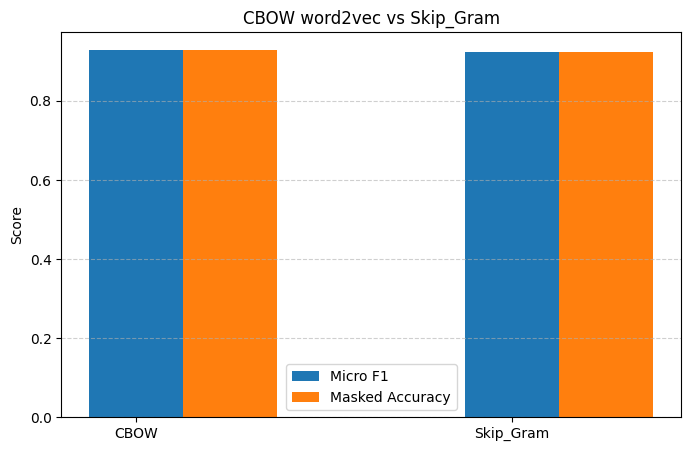

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ["CBOW", "Skip_Gram"]
# Accuracy: 0.92779061794281
# F1: 0.92779061794281
micro_f1 = [0.927, 0.923]
masked_acc = [0.927,0.923]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
# plt.bar(x - width, macro_f1, width, label="Macro F1")
plt.bar(x, micro_f1, width, label="Micro F1")
plt.bar(x + width, masked_acc, width, label="Masked Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("CBOW word2vec vs Skip_Gram")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


Very similre accuracy

In [ ]:
CBOW = {
    "number_step": 4,
    "name_model": "word2vec_CBOW",
    "features": "pretrain embeddings",
    "parameters_model": "class weights",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.927,
    "F-score-macro": 0.927,
    "F-score-micro": None
}
Skip_Gram = {
    "number_step": 5,
    "name_model": "word2vec_Skip_Gram",
    "features": "pretrain embeddings",
    "parameters_model": "class weights",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.923,
    "F-score-macro": 0.923,
    "F-score-micro": None
}
dictionary.append(CBOW)
dictionary.append(Skip_Gram)



># Transfer Learning



In [ ]:
!pip install transformers datasets seqeval

In [ ]:
!pip install --upgrade pandas

In [ ]:
!pip install -q gdown transformers torch datasets accelerate scikit-learn pandas


تحميل ملف البيانات وقراءته على أجزاء (chunks) لتوفير الذاكرة.


In [ ]:
import pandas as pd
import gdown

url = "https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6"
dataset_path = "/tmp/dataset.csv"

gdown.download(url, dataset_path, quiet=False)

chunks = pd.read_csv(dataset_path, chunksize=200000)

chunk = next(chunks)
chunk.sample(10)


Downloading...
From (original): https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6
From (redirected): https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6&confirm=t&uuid=ee601f7b-a281-43c6-aabd-91959f7c2101
To: /tmp/dataset.csv
100%|██████████| 4.68G/4.68G [01:24<00:00, 55.6MB/s]


,word,punct,label_id
196900,١,,0
43323,البلد,,0
171194,تشرين,,0
185518,جوانب,,0
10289,اذار/مارس,,0
110033,فان,,0
110703,ان,,0
156621,والروثينيون,,0
147249,المصير,,0
64802,من,,0


استخراج الكلمات والوسوم

In [ ]:
X = chunk["word"].tolist()
Y = chunk["label_id"].tolist()

for i in range(10):
    print(X[i], "->", Y[i])


ولهذا -> 0
السبب -> 0
قررت -> 0
الحكومة -> 0
التماس -> 0
التمويل -> 0
للصندوق -> 0
من -> 0
مصادر -> 0
خاصة -> 1


 تقسيم الكلمات إلى جمل

In [ ]:
def sequence(words, labels):
    X, Y = [], []
    sent, sent_labels = [], []

    for word, label in zip(words, labels):
        sent.append(word)
        sent_labels.append(label)

        if label in [1, 3, 4]:  # . ؟ !
            X.append(sent)
            Y.append(sent_labels)
            sent, sent_labels = [], []

    if len(sent) > 0:
        X.append(sent)
        Y.append(sent_labels)

    return X, Y

X, Y = sequence(X, Y)

print(X[0])
print(Y[0])


['ولهذا', 'السبب', 'قررت', 'الحكومة', 'التماس', 'التمويل', 'للصندوق', 'من', 'مصادر', 'خاصة']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [ ]:
clean_X, clean_Y = [], []

for sent, labels in zip(X, Y):
    new_sent, new_labels = [], []

    for w, l in zip(sent, labels):
        if isinstance(w, str) and w.strip() != "":
            new_sent.append(w)
            new_labels.append(l)

    if len(new_sent) > 0:
        clean_X.append(new_sent)
        clean_Y.append(new_labels)

print("Deleted samples:", len(X) - len(clean_X))

X = clean_X
Y = clean_Y


Deleted samples: 0


> # Load araBERT model

AraBERT هو نموذج لغوي عميق مبني على بنية BERT (Bidirectional Encoder Representations from Transformers)، لكنه مُدرَّب خصيصًا على اللغة العربية. يهدف إلى فهم النص العربي بدقة أعلى من النماذج العامة، وذلك لأنه أُعيد تصميمه ليتعامل مع خصائص العربية مثل الصرف الغني، وتعدد الصيغ، واختلاف اللهجات، وعلامات التشكيل.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_NAME = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Prepare the data for the model**

In [ ]:
def encode_sentence(words, labels, max_len=64):
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(labels[word_idx])
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx

    encoding["labels"] = torch.tensor(label_ids)
    return encoding


In [ ]:
encoded_data = []
# max_len = max(len(s) for s in X)
for sent, lab in zip(X, Y):
    encoded_data.append(encode_sentence(sent, lab,max_len=128))


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    encoded_data,
    test_size=0.2,
    random_state=42
)


إنشاء Dataset خاص بـ PyTorch

In [ ]:
class PunctuationDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return {k: v.squeeze(0) for k, v in self.data[idx].items()}


In [ ]:
train_dataset = PunctuationDataset(train_data)
val_dataset   = PunctuationDataset(val_data)


**Function to compute accuracy with ignoring (-100) padding and compute the F1 score**

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels =  eval_pred.label_ids
    predictions = np.argmax(logits, axis=-1)

    true_labels = []
    true_preds  = []

    for pred_seq, label_seq in zip(predictions, labels):
        for p, l in zip(pred_seq, label_seq):
            if l != -100:  # تجاهل padding و subwords
                true_labels.append(l)
                true_preds.append(p)

    accuracy = accuracy_score(true_labels, true_preds)
    micro_f1 = f1_score(true_labels, true_preds, average="micro")
    macro_f1 = f1_score(true_labels, true_preds, average="macro")

    return {
        "accuracy": accuracy,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1
    }


**Train the Model**

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    report_to="none"
)


In [ ]:
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()


/tmp/ipython-input-1101192430.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Micro F1,Macro F1
1,0.103600,0.088280,0.964562,0.964562,0.508206
2,0.071100,0.084904,0.966847,0.966847,0.561818
3,0.052500,0.091725,0.966647,0.966647,0.604272
4,0.035200,0.104505,0.965240,0.965240,0.618691
5,0.025000,0.118135,0.967752,0.967752,0.621780


TrainOutput(global_step=3865, training_loss=0.06551247543690275, metrics={'train_runtime': 883.1027, 'train_samples_per_second': 35.013, 'train_steps_per_second': 4.377, 'total_flos': 2019915235092480.0, 'train_loss': 0.06551247543690275, 'epoch': 5.0})

بشكل عام تشير هذه النتائج إلى أن النموذج تعلّم المهمة بكفاءة مع أفضل توازن بين الأداء والتعميم يتحقق في epoch الأولى بينما تتطلب epoch المتأخرة تقنيات إضافية مثل التوقف المبكر (Early Stopping) أو تنظيم النموذج (Regularization) للحد من فرط التعلّم

In [ ]:
preds = trainer.predict(val_dataset)
compute_metrics(preds)

{'accuracy': 0.9677516576250753,
 'micro_f1': 0.9677516576250753,
 'macro_f1': 0.6217795752709856}

**Plot the training curve**

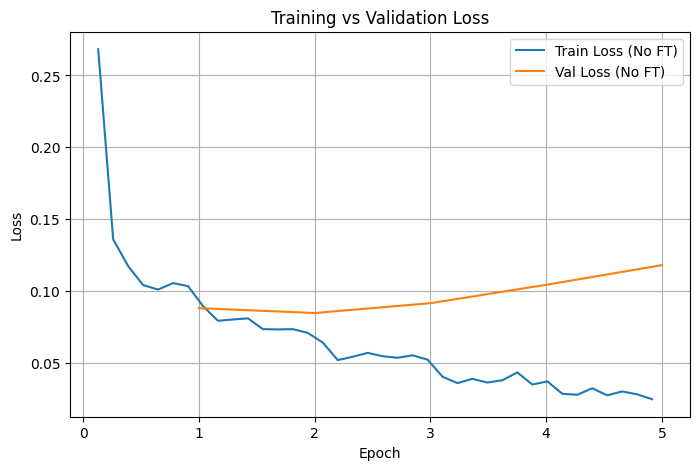

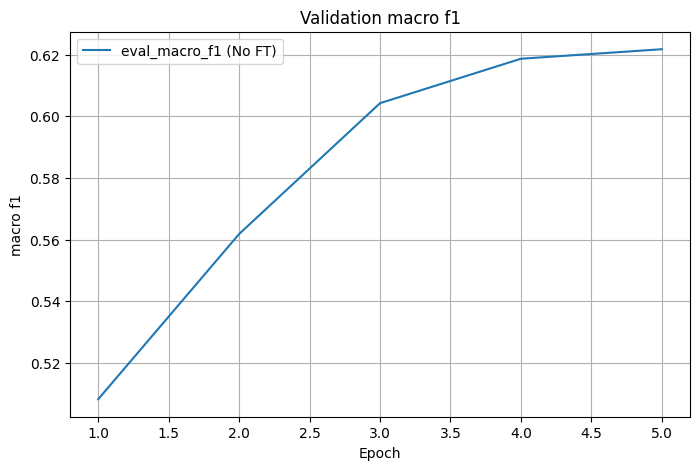

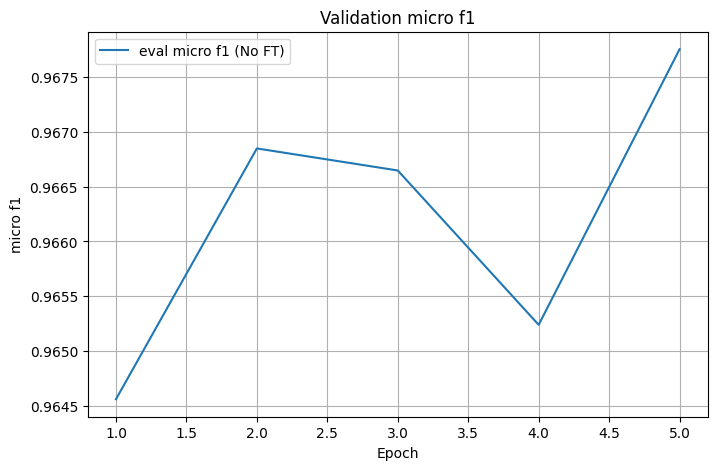

In [ ]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()][["epoch", "loss"]]
val_loss   = df[df["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8,5))

plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss (No FT)")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Val Loss (No FT)")



plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

metrics = df[df["eval_accuracy"].notna()][
    ["epoch", "eval_accuracy", "eval_micro_f1", "eval_macro_f1"]
]

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_macro_f1"], label="eval_macro_f1 (No FT)")

plt.xlabel("Epoch")
plt.ylabel("macro f1")
plt.title("Validation macro f1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_micro_f1"], label="eval micro f1 (No FT)")

plt.xlabel("Epoch")
plt.ylabel("micro f1")
plt.title("Validation micro f1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
label_map = {
    0: "",
    1: ".",
    2: "،",
    3: "؟",
    4: "!",
    5: ":",
    6: "؛"
}


تجربة النموذج على جملة جديدة

In [ ]:
def predict_punctuation(words):
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(**encoding)

    preds = torch.argmax(outputs.logits, dim=-1)[0].tolist()
    word_ids = encoding.word_ids()

    result = []
    used = set()

    for i, word_id in enumerate(word_ids):
        if word_id is not None and word_id not in used:
            used.add(word_id)
            result.append(words[word_id] + label_map[preds[i]])

    return " ".join(result)


In [ ]:
test_sentence = ["أكل", "الولد", "الخبز", "وشرب", "الماء"]
print(predict_punctuation(test_sentence))


أكل الولد الخبز وشرب الماء.




> # Now train with fine-tuning



In [ ]:
model_with_FN = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7
)

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


*First freez the embedding gradens*

In [ ]:
for param in model_with_FN.bert.embeddings.parameters():
    param.requires_grad = False

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16 = True
)


**Train the Model while the layers are freezed**

In [ ]:
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model_with_FN,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)

trainer.train()


/tmp/ipython-input-3092834007.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Micro F1,Macro F1
1,0.099400,0.086027,0.965466,0.965466,0.524260
2,0.065300,0.084881,0.967651,0.967651,0.548901
3,0.043500,0.103436,0.966822,0.966822,0.612637
4,0.018200,0.123113,0.966822,0.966822,0.616725
5,0.009100,0.156732,0.968580,0.968580,0.617061


TrainOutput(global_step=3865, training_loss=0.053275325905922, metrics={'train_runtime': 537.9366, 'train_samples_per_second': 57.479, 'train_steps_per_second': 7.185, 'total_flos': 2019915235092480.0, 'train_loss': 0.053275325905922, 'epoch': 5.0})

*Unfreeze the embedding layers*

In [ ]:
for param in model_with_FN.bert.embeddings.parameters():
    param.requires_grad = True

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    report_to="none",
    # fp16 = True
)


**Now trin the full model**

In [ ]:
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model_with_FN,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)

trainer.train()


/tmp/ipython-input-3004131813.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Micro F1,Macro F1
1,0.009400,0.188001,0.968530,0.968530,0.590685
2,0.003000,0.206795,0.967877,0.967877,0.604563
3,0.002900,0.218650,0.967576,0.967576,0.612039
4,0.003300,0.228919,0.967601,0.967601,0.621288
5,0.002500,0.241003,0.968103,0.968103,0.622348


TrainOutput(global_step=3865, training_loss=0.0038365081415293596, metrics={'train_runtime': 656.1427, 'train_samples_per_second': 47.124, 'train_steps_per_second': 5.89, 'total_flos': 2019915235092480.0, 'train_loss': 0.0038365081415293596, 'epoch': 5.0})

In [ ]:
preds = trainer.predict(val_dataset)
compute_metrics(preds)

{'accuracy': 0.9681032750653004,
 'micro_f1': 0.9681032750653004,
 'macro_f1': 0.6223478009223045}

**Plot the training curve**

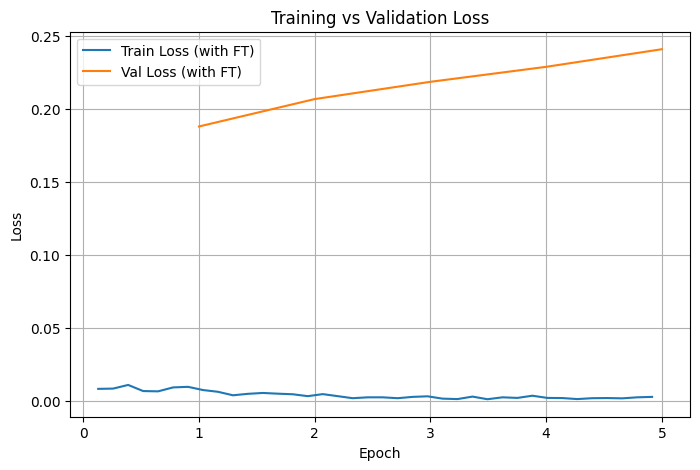

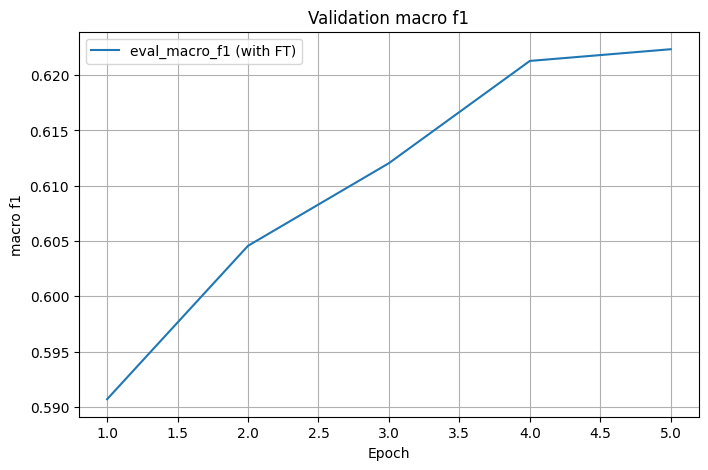

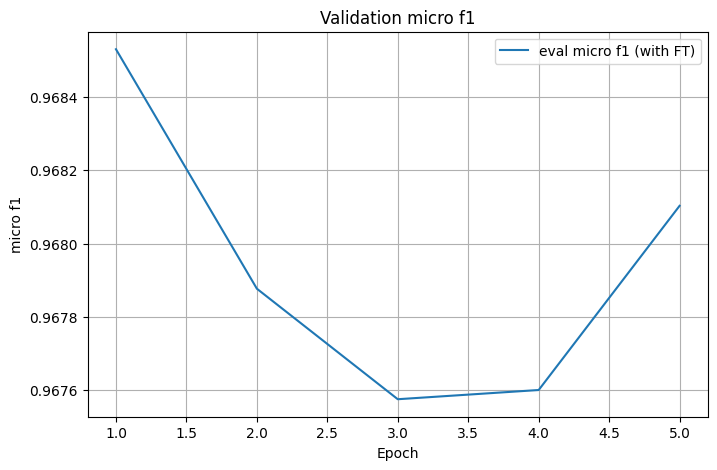

In [ ]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()][["epoch", "loss"]]
val_loss   = df[df["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8,5))

plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss (with FT)")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Val Loss (with FT)")



plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

metrics = df[df["eval_accuracy"].notna()][
    ["epoch", "eval_accuracy", "eval_micro_f1", "eval_macro_f1"]
]

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_macro_f1"], label="eval_macro_f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("macro f1")
plt.title("Validation macro f1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_micro_f1"], label="eval micro f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("micro f1")
plt.title("Validation micro f1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

path = "/content/drive/MyDrive/arabert_finetuned_model_F"

model_with_FN.save_pretrained(path)
tokenizer.save_pretrained(path)

('/content/drive/MyDrive/arabert_finetuned_model_F/tokenizer_config.json',
 '/content/drive/MyDrive/arabert_finetuned_model_F/special_tokens_map.json',
 '/content/drive/MyDrive/arabert_finetuned_model_F/vocab.txt',
 '/content/drive/MyDrive/arabert_finetuned_model_F/added_tokens.json',
 '/content/drive/MyDrive/arabert_finetuned_model_F/tokenizer.json')

# **Compare between the model without fine-tuning and with fine-tuining**

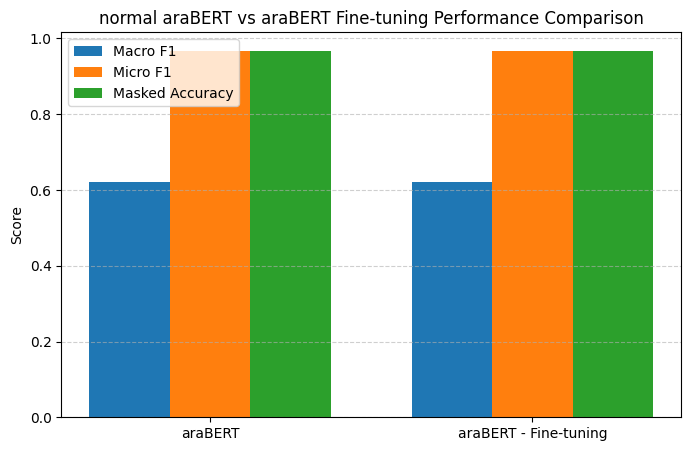

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ["araBERT", "araBERT - Fine-tuning"]
# {'accuracy': 0.9677516576250753,
#  'micro_f1': 0.9677516576250753,
#  'macro_f1': 0.6217795752709856}
#  {'accuracy': 0.9678018886879647,
#  'micro_f1': 0.9678018886879647,
#  'macro_f1': 0.6181109132886856}
# {'accuracy': 0.9681032750653004,
#  'micro_f1': 0.9681032750653004,
#  'macro_f1': 0.6223478009223045}
macro_f1 = [0.621, 0.622]
micro_f1 = [0.967, 0.968]
masked_acc = [0.967,0.968]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, macro_f1, width, label="Macro F1")
plt.bar(x, micro_f1, width, label="Micro F1")
plt.bar(x + width, masked_acc, width, label="Masked Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("normal araBERT vs araBERT Fine-tuning Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


على الرغم من استخدام fine-tuning إلا أن النموذج لم يتحسن كثيراً وهذا يدل على قوة نموذج araBERT في التعامل مع اللغة العربية

> # We will use the Fine-tuning model but adding weighted loss

مع استخدام weighted loss نجبر النموذج على الأهتمام بإشارات الأقل تكراراً وبذلك نحسن الأداء ونتغلب على مشكلة Unbalanced dataset



In [ ]:
import pandas as pd
import gdown

url = "https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6"
dataset_path = "/tmp/dataset.csv"

gdown.download(url, dataset_path, quiet=False)

chunks_new = pd.read_csv(dataset_path, skiprows=range(1, 200001), chunksize=200000)

chunks_new = next(chunks_new)
chunks_new.sample(10)


Downloading...
From (original): https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6
From (redirected): https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6&confirm=t&uuid=8e2fd322-eca6-4a5f-8de6-0df9888ca030
To: /tmp/dataset.csv
100%|██████████| 4.68G/4.68G [01:33<00:00, 50.2MB/s]


,word,punct,label_id
196900,يلزم,,0
43323,الوارد,,0
171194,تطبق,,0
185518,٥٨٨١,,0
10289,يحول,,0
110033,مناهضة,,0
110703,١,:,5
156621,في,,0
147249,نيكولز,،,2
64802,لاحق,،,2


In [ ]:
X = chunks_new["word"].tolist()
Y = chunks_new["label_id"].tolist()

for i in range(10):
    print(X[i], "->", Y[i])


لم -> 0
تفعل -> 0
ذلك -> 0
بعد -> 2
بالتوقيع -> 0
والتصديق -> 0
على -> 0
اتفاقية -> 0
قمع -> 0
الاتجار -> 0


In [ ]:
def sequence(words, labels):
    X, Y = [], []
    sent, sent_labels = [], []

    for word, label in zip(words, labels):
        sent.append(word)
        sent_labels.append(label)

        if label in [1, 3, 4]:  # . ؟ !
            X.append(sent)
            Y.append(sent_labels)
            sent, sent_labels = [], []

    if len(sent) > 0:
        X.append(sent)
        Y.append(sent_labels)

    return X, Y

X, Y = sequence(X, Y)

print(X[0])
print(Y[0])


['لم', 'تفعل', 'ذلك', 'بعد', 'بالتوقيع', 'والتصديق', 'على', 'اتفاقية', 'قمع', 'الاتجار', 'بالاشخاص', 'واستغلال', 'دعارة', 'الغير', 'واتفاقية', 'لاهاي', 'بشان', 'الولاية', 'القضائية', 'والقانون', 'الواجب', 'التطبيق', 'والاعتراف', 'بالمراسيم', 'المتعلقة', 'بالتبني', ')٥٦٩١(', 'والاتفاقية', 'الاوروبية', 'بشان', 'تبني', 'الاطفال', ')٧٦٩١(', 'واتفاقية', 'منظمة', 'العمل', 'الدولية', 'رقم', '٨٣١', 'بشان', 'الحد', 'الادنى', 'لسن', 'الاستخدام', ')٣٧٩١(', 'واتفاقية', 'حقوق', 'الطفل', ')٩٨٩١(؛)ب(', 'وضع', 'قواعد', 'عن', 'الولاية', 'القضائية', 'خارج', 'الاقليم', 'الوطني', 'بغية', 'اتاحة', 'ملاحقة', 'ومعاقبة', 'المواطنين', 'الذين', 'ارتكبوا', 'جرائم', 'تتعلق', 'بالاستغلال', 'الجنسي', 'للاطفال', 'خارج', 'الاقليم', 'الوطني', 'او', 'عند', 'الاقتضاء', 'استعراض', 'القواعد', 'القائمة', 'لهذا', 'الغرض', 'وتحسين', 'التعاون', 'الدولي', 'لهذه', 'الغاية؛)ج(', 'زيادة', 'وتحسين', 'تبادل', 'المعلومات', 'بين', 'البلدان', 'من', 'خلال', 'المنظمة', 'الدولية', 'للشرطة', 'الجنائية', 'بغية', 'كشف', 'وملاحقة', 'المجرمين

In [ ]:
clean_X, clean_Y = [], []

for sent, labels in zip(X, Y):
    new_sent, new_labels = [], []

    for w, l in zip(sent, labels):
        if isinstance(w, str) and w.strip() != "":
            new_sent.append(w)
            new_labels.append(l)

    if len(new_sent) > 0:
        clean_X.append(new_sent)
        clean_Y.append(new_labels)

print("Deleted samples:", len(X) - len(clean_X))

X = clean_X
Y = clean_Y


Deleted samples: 0


In [ ]:
def encode_sentence(words, labels, max_len=64):
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(labels[word_idx])
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx

    encoding["labels"] = torch.tensor(label_ids)
    return encoding


In [ ]:
encoded_data = []
# max_len = max(len(s) for s in X)
for sent, lab in zip(X, Y):
    encoded_data.append(encode_sentence(sent, lab,max_len=128))


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    encoded_data,
    test_size=0.1,
    random_state=42
)


In [ ]:
class PunctuationDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return {k: v.squeeze(0) for k, v in self.data[idx].items()}


In [ ]:
train_dataset = PunctuationDataset(train_data)
val_dataset   = PunctuationDataset(val_data)


# **Weighted Trainer for weighted loss**

In [ ]:
import torch
import torch.nn.functional as F
from transformers import Trainer

class_weights = torch.tensor([0.1, 1.0, 1.3, 3.0, 2.5, 3.2, 3.5], dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss = F.cross_entropy(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
            weight=class_weights.to(logits.device),
            ignore_index=-100
        )

        return (loss, outputs) if return_outputs else loss


In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16 = True
)


In [ ]:
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model_with_FN,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)

trainer.train()


/tmp/ipython-input-4067802618.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Epoch,Training Loss,Validation Loss,Accuracy,Micro F1,Macro F1
1,0.188000,0.179228,0.947255,0.947255,0.669717
2,0.116600,0.201229,0.953750,0.953750,0.677416
3,0.129400,0.272579,0.964278,0.964278,0.846105
4,0.061900,0.372456,0.966164,0.966164,0.851884
5,0.061300,0.470415,0.969987,0.969987,0.877541


TrainOutput(global_step=4325, training_loss=0.11528552220735935, metrics={'train_runtime': 682.877, 'train_samples_per_second': 50.661, 'train_steps_per_second': 6.333, 'total_flos': 2259992482471680.0, 'train_loss': 0.11528552220735935, 'epoch': 5.0})

In [ ]:
preds = trainer.predict(val_dataset)
compute_metrics(preds)

{'accuracy': 0.9699874292897549,
 'micro_f1': 0.9699874292897549,
 'macro_f1': 0.8775410851751663}

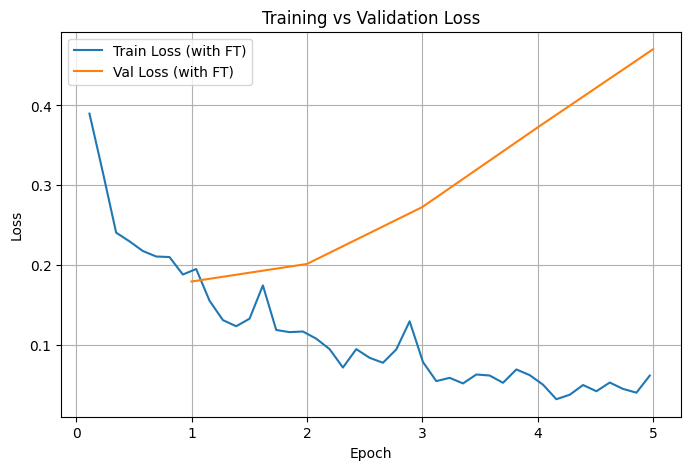

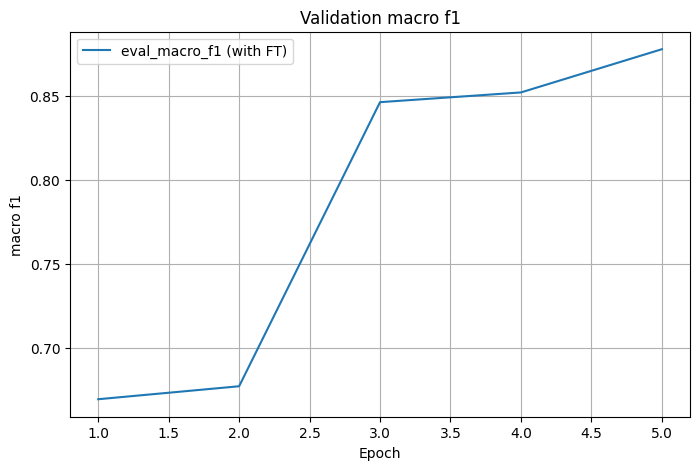

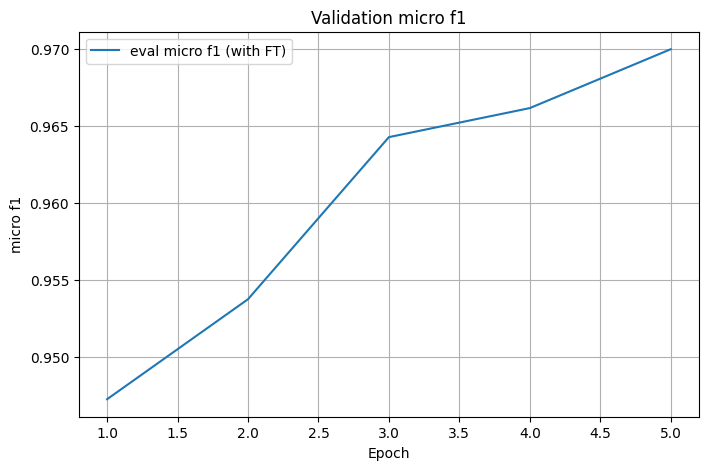

In [ ]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()][["epoch", "loss"]]
val_loss   = df[df["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8,5))

plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss (with FT)")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Val Loss (with FT)")



plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

metrics = df[df["eval_accuracy"].notna()][
    ["epoch", "eval_accuracy", "eval_micro_f1", "eval_macro_f1"]
]

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_macro_f1"], label="eval_macro_f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("macro f1")
plt.title("Validation macro f1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_micro_f1"], label="eval micro f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("micro f1")
plt.title("Validation micro f1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# trainer.save_model("/content/drive/MyDrive/arabert_weighted")
from transformers import AutoModelForTokenClassification, AutoTokenizer

path = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss"

model_with_FN.save_pretrained(path)
tokenizer.save_pretrained(path)

('/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss/tokenizer_config.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss/special_tokens_map.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss/vocab.txt',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss/added_tokens.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss/tokenizer.json')

# **Compare between the model without fine-tuning and with fine-tuining and fine-tuining with weighed loss**

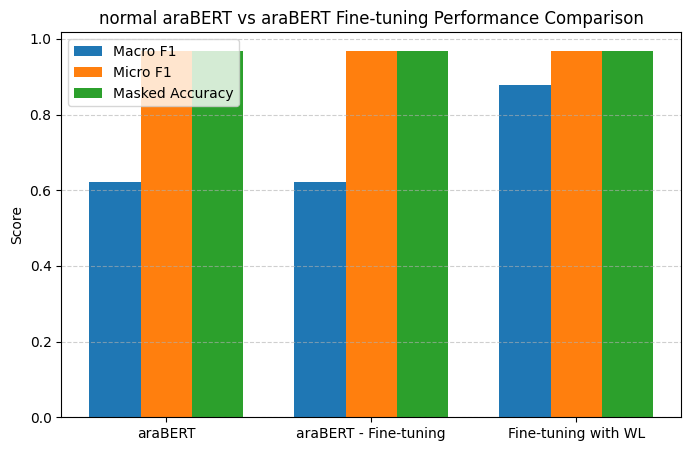

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ["araBERT", "araBERT - Fine-tuning","Fine-tuning with WL"]
# {'accuracy': 0.9677516576250753,
#  'micro_f1': 0.9677516576250753,
#  'macro_f1': 0.6217795752709856}
#  {'accuracy': 0.9678018886879647,
#  'micro_f1': 0.9678018886879647,
#  'macro_f1': 0.6181109132886856}
# {'accuracy': 0.9681032750653004,
#  'micro_f1': 0.9681032750653004,
#  'macro_f1': 0.6223478009223045}
# {'accuracy': 0.9699874292897549,
#  'micro_f1': 0.9699874292897549,
#  'macro_f1': 0.8775410851751663}
macro_f1 = [0.621, 0.622,0.877]
micro_f1 = [0.967, 0.968,0.969]
masked_acc = [0.967,0.968,0.969]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, macro_f1, width, label="Macro F1")
plt.bar(x, micro_f1, width, label="Micro F1")
plt.bar(x + width, masked_acc, width, label="Masked Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("normal araBERT vs araBERT Fine-tuning Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


نلاحظ تحسن جيد إلى حد كبير في F1-macro بعد استخدام weighted loss

In [ ]:
models = ["araBERT", "araBERT - Fine-tuning","Fine-tuning with WL"]
macro_f1 = [0.621, 0.622,0.877]
micro_f1 = [0.967, 0.968,0.969]
masked_acc = [0.967,0.968,0.969]
araBERT_base = {
    "number_step": 6,
    "name_model": "araBERT",
    "features": "Contextual subword embeddings",
    "parameters_model": "default",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.967,
    "F-score-macro": 0.621,
    "F-score-micro": 0.967
}
araBERT_ft = {
    "number_step": 7,
    "name_model": "araBERT - Fine-tuning",
    "features": "Contextual subword embeddings",
    "parameters_model": "Fine-tuning",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.968,
    "F-score-macro": 0.622,
    "F-score-micro": 0.968
}
araBERT_ft_wl = {
    "number_step": 8,
    "name_model": "Fine-tuning with WL",
    "features": "Contextual subword embeddings",
    "parameters_model": "Fine-tuning + class weights",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.969,
    "F-score-macro": 0.877,
    "F-score-micro": 0.969
}
dictionary.append(araBERT_base)
dictionary.append(araBERT_ft)
dictionary.append(araBERT_ft_wl)




> # Cmoparing the Best Models (Weighted BiLSTM, CBOW embedding, weighted araBERT with Fine-tuning)



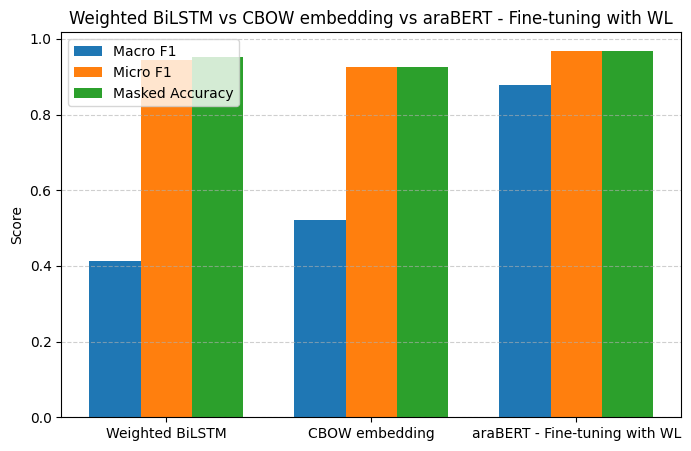

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
models = ["Weighted BiLSTM", "CBOW embedding","araBERT - Fine-tuning with WL"]
# macro_f1 = [0.106, 0.266,0.412]
# micro_f1 = [0.167, 0.598,0.943]
# masked_acc = [0.17, 0.60,0.9510]
macro_f1 = [0.412, 0.522,0.877]
micro_f1 = [0.943, 0.927,0.969]
masked_acc = [0.9510,0.927,0.969]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, macro_f1, width, label="Macro F1")
plt.bar(x, micro_f1, width, label="Micro F1")
plt.bar(x + width, masked_acc, width, label="Masked Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Weighted BiLSTM vs CBOW embedding vs araBERT - Fine-tuning with WL")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


النموذج araBERT أبدى أقوى قيم من الدقة و F1-score

The Best Model among them is *araBERT - Fine-tuning with WL*

# الآن لنختبر النموذج على داتا جديدة لم يتعلم عليها مسبقاً ونعرض مصفوفة التعارض  *araBERT - Fine-tuning with WL*

# Load new Data to test the model for confusion matrix

In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

path = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2"

tokenizer = AutoTokenizer.from_pretrained(path)

model = AutoModelForTokenClassification.from_pretrained(path)

In [ ]:
import pandas as pd
import gdown

# url = "https://drive.google.com/uc?id=1sQppeJ4RMzuUmwaZFe7Xfa2q8kiImWR6"
# dataset_path = "/tmp/dataset.csv"

# gdown.download(url, dataset_path, quiet=False)

chunks_new = pd.read_csv("/content/drive/MyDrive/F_dataset/dataset.csv", skiprows=range(1, 400001), chunksize=200000)

chunks_new = next(chunks_new)
chunks_new.sample(10)

,word,punct,label_id
119737,جميع,,0
72272,جهاز,,0
158154,ورسائل,,0
65426,او,,0
30074,برسالة,,0
23677,دانا,,0
134858,هذه,,0
176418,ارض,,0
132467,اللجنة,,0
4082,كارلوس,,0


In [ ]:
X = chunks_new["word"].tolist()
Y = chunks_new["label_id"].tolist()

for i in range(10):
    print(X[i], "->", Y[i])


افيد -> 0
بانه -> 0
اعتقل -> 0
مع -> 0
عدد -> 0
من -> 0
الاشخاص -> 0
الاخرين -> 0
في -> 0
نيسان/ابريل -> 0


In [ ]:
def sequence(words, labels):
    X, Y = [], []
    sent, sent_labels = [], []

    for word, label in zip(words, labels):
        sent.append(word)
        sent_labels.append(label)

        if label in [1, 3, 4]:  # . ؟ !
            X.append(sent)
            Y.append(sent_labels)
            sent, sent_labels = [], []

    if len(sent) > 0:
        X.append(sent)
        Y.append(sent_labels)

    return X, Y

X, Y = sequence(X, Y)

print(X[0])
print(Y[0])


['افيد', 'بانه', 'اعتقل', 'مع', 'عدد', 'من', 'الاشخاص', 'الاخرين', 'في', 'نيسان/ابريل', '٥٩٩١', 'بعد', 'نفيهم', 'من', 'نيبال']
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [ ]:
clean_X, clean_Y = [], []

for sent, labels in zip(X, Y):
    new_sent, new_labels = [], []

    for w, l in zip(sent, labels):
        if isinstance(w, str) and w.strip() != "":
            new_sent.append(w)
            new_labels.append(l)

    if len(new_sent) > 0:
        clean_X.append(new_sent)
        clean_Y.append(new_labels)

print("Deleted samples:", len(X) - len(clean_X))

X = clean_X
Y = clean_Y


Deleted samples: 1


In [ ]:
def encode_sentence(words, labels, max_len=64):
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(labels[word_idx])
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx

    encoding["labels"] = torch.tensor(label_ids)
    return encoding


In [ ]:
encoded_data = []
# max_len = max(len(s) for s in X)
for sent, lab in zip(X, Y):
    encoded_data.append(encode_sentence(sent, lab,max_len=128))


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    encoded_data,
    test_size=0.1,
    random_state=42
)


In [ ]:
class PunctuationDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return {k: v.squeeze(0) for k, v in self.data[idx].items()}


In [ ]:
train_dataset = PunctuationDataset(train_data)
val_dataset   = PunctuationDataset(val_data)




> # Now to test the best mdoel and dreaw Confising Metrix


In [ ]:
import numpy as np

def get_predictions(model, dataset, device):
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in dataset:
            input_ids = batch["input_ids"].unsqueeze(0).to(device)
            attention_mask = batch["attention_mask"].unsqueeze(0).to(device)
            labels = batch["labels"].unsqueeze(0).to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=-1)

            # flatten + ignore padding
            for p, l in zip(preds.view(-1), labels.view(-1)):
                if l != -100:
                    all_preds.append(p.item())
                    all_labels.append(l.item())

    return np.array(all_labels), np.array(all_preds)


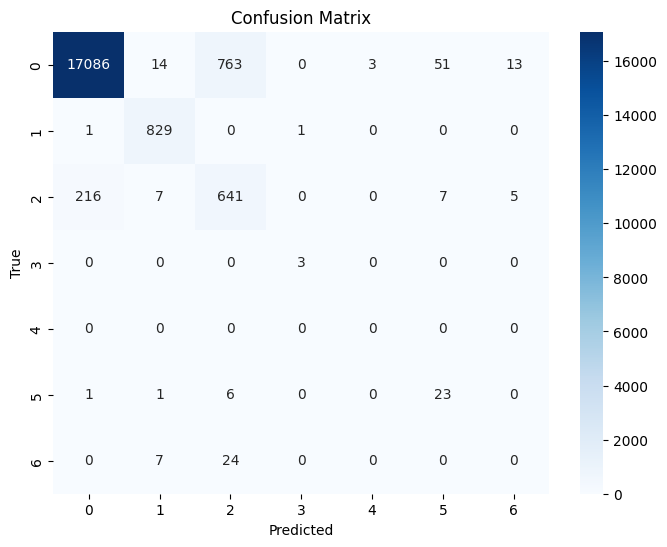

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
labels, preds = get_predictions(model, val_dataset, device)
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import f1_score

def evaluate_macro_f1(model, dataloader, device,labels,preds):
    # labels, preds = get_predictions(model, dataloader, device)
    return f1_score(labels, preds, average="macro")
def evaluate_wighted_f1(model, dataloader, device,labels,preds):
    # labels, preds = get_predictions(model, dataloader, device)
    return f1_score(labels, preds, average="weighted")
test_macro_f1 = evaluate_macro_f1(model, val_dataset, device,labels,preds)
test_weighted_f1 = evaluate_wighted_f1(model, val_dataset, device,labels,preds)

print(f"Test Macro-F1:       {test_macro_f1:.4f}")
print(f"Test Weighted-F1:    {test_weighted_f1:.4f}")


Test Macro-F1:       0.5392
Test Weighted-F1:    0.9495




> # Train on medcine dataset



In [ ]:
from datasets import load_dataset

dataset_name = "Ahmed-Selem/Shifaa_Arabic_Medical_Consultations"

try:
    dataset = load_dataset(dataset_name)
    print(f"Successfully downloaded dataset: {dataset_name}")
    print(dataset)
except Exception as e:
    print(f"Error downloading dataset {dataset_name}: {e}")

import pandas as pd

df = dataset['train'].to_pandas()
print("Dataset converted to pandas DataFrame. Displaying the first 5 rows:")
# display(df.head())

df['Main Category'] = df['Hierarchical Diagnosis'].apply(lambda x: x.split(' - ')[0] if isinstance(x, str) and ' - ' in x else x)

print("Added 'main category' column. Displaying the first 5 rows with the new column:")
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Nervous_System_Diseases.csv:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Blood_Diseases_and_Oncology.csv:   0%|          | 0.00/10.4M [00:00<?, ?B/s]

...

Pharmaceuticals_and_Preparations.csv:   0%|          | 0.00/46.6M [00:00<?, ?B/s]

Obstetrics_and_Gynecology.csv:   0%|          | 0.00/56.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/84422 [00:00<?, ? examples/s]

Successfully downloaded dataset: Ahmed-Selem/Shifaa_Arabic_Medical_Consultations
DatasetDict({
    train: Dataset({
        features: ['Question Title', 'Question', 'Answer', 'Doctor Name', 'Consultation Number', 'Date of Answer', 'Hierarchical Diagnosis'],
        num_rows: 84422
    })
})
Dataset converted to pandas DataFrame. Displaying the first 5 rows:
Added 'main category' column. Displaying the first 5 rows with the new column:


,Question Title,Question,Answer,Doctor Name,Consultation Number,Date of Answer,Hierarchical Diagnosis,Main Category
0,هل ارتفاع اليوزينيات في تحليل الدم تدل على أمر...,السلام عليكم\nالشكر الجزيل لكل من يسهر على هذه...,بسم الله الرحمن الرحيم\nالأخت الفاضلة/ مريم حف...,د. عطية إبراهيم محمد,2549588,2024-09-19,أمراض الدم والأورام - أمراض الدم - أخرى,أمراض الدم والأورام
1,هل يوجد إشكال في اختلاف فصيلة الدم بين الزوجين؟,السلام عليكم\n\nتزوجت من قريبتي وكانت زمرة الد...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ مصعب حفظه...,د. كندا تركي العابد,2530722,2023-12-25,أمراض الدم والأورام - أمراض الدم - أخرى,أمراض الدم والأورام
2,اختلاف فصيلة دم الأم والطفل هل يؤثر على حياة ا...,السلام عليكم ورحمة الله وبركاته\n\nإذا كانت فص...,بسم الله الرحمن الرحيم\nالأخت الفاضلة/ Zehra ح...,د. حاتم محمد أحمد,2526579,2023-11-29,أمراض الدم والأورام - أمراض الدم - أخرى,أمراض الدم والأورام
3,عملية استئصال الطحال وعلاقتها بمرض الكريات الح...,عندي مرض كثرة الكريات الحمراء الكروية الوراثي،...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ حسام حفظه...,د. محمد مازن,2523308,2023-11-16,أمراض الدم والأورام - أمراض الدم - أخرى,أمراض الدم والأورام
4,ما هي المدة اللازمة لعلاج طفلي من حمى البحر ال...,السلام عليكم ورحمة الله وبركاته.\n\nابني عمره ...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ Ali حفظه ...,د. عطية إبراهيم محمد,2518451,2023-09-13,أمراض الدم والأورام - أمراض الدم - أخرى,أمراض الدم والأورام


In [ ]:
internal_med_ds = df[
    df["Main Category"] == "أمراض الباطنية والصدر"
]

print("Number of internal medicine samples:", len(internal_med_ds))
display(internal_med_ds.head())

# internal_med_ds.to_csv("shifaa_internal_medicine.csv")

Number of internal medicine samples: 11841


,Question Title,Question,Answer,Doctor Name,Consultation Number,Date of Answer,Hierarchical Diagnosis,Main Category
28200,أصبت بالنزف الشرجي، فهل تنصحوني بعمل منظار؟,السلام عليكم.\n\nحدث نزف شرجي بكمية بسيطة، است...,بسم الله الرحمن الرحيم\nالأخت الفاضلة/ ر.ع.ح ح...,د. محمد مازن,2526693,2023-12-09,أمراض الباطنية والصدر - مشاكل القولون - سرطان ...,أمراض الباطنية والصدر
28201,خروج قطع حمراء مع البراز، هل يشير إلى سرطان ال...,السلام عليكم.\n\nعمري 18 سنة، منذ 4 أيام لاحظت...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ فهد حفظه ...,د. عطية إبراهيم محمد,2488067,2022-08-08,أمراض الباطنية والصدر - مشاكل القولون - سرطان ...,أمراض الباطنية والصدر
28202,والدتي تعاني من سرطان الرئة اليمنى، ما العلاج؟,السلام عليكم\n\nوالدتي كانت تعاني منذ 6 سنوات ...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ سمير حفظه...,د. محمد حمودة,2392188,2019-03-03,أمراض الباطنية والصدر - مشاكل القولون - سرطان ...,أمراض الباطنية والصدر
28203,السرطان هل يختفي نهائيا بعد العملية، أم يعود م...,السلام عليكم\n\nأمي كانت تشتكي من وجود دم في ا...,بسم الله الرحمن الرحيم.\nالأخ الفاضل/ محمد حفظ...,د. محمد مازن,2375355,2018-07-25,أمراض الباطنية والصدر - مشاكل القولون - سرطان ...,أمراض الباطنية والصدر
28204,أعاني من مشكلة القولون واختلاط الدم بالبراز,السلام عليكم\n\nعمري 23 سنة، أعاني من مشاكل في...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ Abdelrahm...,د. محمد مازن,2362215,2018-02-11,أمراض الباطنية والصدر - مشاكل القولون - سرطان ...,أمراض الباطنية والصدر


In [ ]:
import re

punct = {'.':1,'،':2,'؟':3,'!':4,':':5,'؛':6,' ':0}

def encoding_word_medcine(example):
    text = (
        example.get("Question Title", "") + " " +
        example.get("Question", "") + " " +
        example.get("Answer", "")
    )

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words_without_puncts = []
    label_ids = []

    for word in words:
        match = re.match(r"(.*?)([،\.\؟\!\:\؛])?$", word)
        clean = match.group(1)
        puncts = match.group(2) if match.group(2) in punct else " "

        words_without_puncts.append(clean)
        label_ids.append(punct[puncts])

    return {
        "word": words_without_puncts,
        "label_id": label_ids
    }
encoded_rows = internal_med_ds.apply(encoding_word_medcine, axis=1)

X = encoded_rows.apply(lambda x: x["word"]).tolist()
Y = encoded_rows.apply(lambda x: x["label_id"]).tolist()

print(len(X), len(Y))
print(X[0][:20])
print(Y[0][:20])

11841 11841
['أصبت', 'بالنزف', 'الشرجي', 'فهل', 'تنصحوني', 'بعمل', 'منظار', 'السلام', 'عليكم', 'حدث', 'نزف', 'شرجي', 'بكمية', 'بسيطة', 'استمر', 'لخمسة', 'أيام', 'وتوقف', 'بعد', 'تناول']
[0, 0, 2, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0]


In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

path = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss"

tokenizer = AutoTokenizer.from_pretrained(path)

model = AutoModelForTokenClassification.from_pretrained(path)

In [ ]:
import torch
def encode_sentence(words, labels, max_len=128):
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(labels[word_idx])
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx

    encoding["labels"] = torch.tensor(label_ids)
    return encoding
encoded_data =[]
for sent, lab in zip(X, Y):
    encoded_data.append(encode_sentence(sent, lab, max_len=128))

print(len(encoded_data))
print(encoded_data[0].keys())


11841
KeysView({'input_ids': tensor([[    2, 58028,  1245, 10171,  1070,  1767,  5164, 40354,  1314,  6670,
         46759,  1624, 10064,  2272, 54144,  1396,  1767, 32935,  8814,  5579,
         36169,  1929, 18559,   446,  3247, 16490, 50376,   372,  5886,   462,
           185,   354,  1898, 20040,   201, 11082,  1482,   342,   225, 42302,
         10623, 10746, 28664,  5065,   323,  6589, 16252,   193,   868,  9864,
           193, 30842, 10392,   228,  7783,  4575, 31565,   391, 30279, 59585,
          2616, 19622,     1,  2776, 12324, 43662, 13750,   421,   871, 26530,
         12324,   680,   305, 32850,  1070,   184, 51870,  1462,   776,   817,
         12800,   394, 50234,   753, 21797, 47616,   307,     1,  1980,  4913,
         36262,    19, 25985,   647,    19,  5164, 40354,  1314,  6670, 46759,
         16761,   352,  3465, 59585,  1059,  1217,   418,  1532, 40019,  7148,
           319,   461,  7837,     1,   722,  6169,  4563,   422,   602,  6425,
           181, 20719, 

In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    encoded_data,
    test_size=0.3,
    random_state=42
)
class PunctuationDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return {k: v.squeeze(0) for k, v in self.data[idx].items()}
train_dataset = PunctuationDataset(train_data)
val_dataset   = PunctuationDataset(val_data)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels =  eval_pred.label_ids
    predictions = np.argmax(logits, axis=-1)

    true_labels = []
    true_preds  = []

    for pred_seq, label_seq in zip(predictions, labels):
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_labels.append(l)
                true_preds.append(p)

    accuracy = accuracy_score(true_labels, true_preds)
    micro_f1 = f1_score(true_labels, true_preds, average="micro")
    macro_f1 = f1_score(true_labels, true_preds, average="macro")

    return {
        "accuracy": accuracy,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1
    }


In [ ]:
import torch
import torch.nn.functional as F
from transformers import Trainer

class_weights = torch.tensor([0.1, 1.0, 1.3, 3.0, 2.5, 3.2, 3.5], dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss = F.cross_entropy(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
            weight=class_weights.to(logits.device),
            ignore_index=-100
        )

        return (loss, outputs) if return_outputs else loss


In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16 = True
)


In [ ]:
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)

trainer.train()


/tmp/ipython-input-55099798.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


Epoch,Training Loss,Validation Loss,Accuracy,Micro F1,Macro F1
1,0.297100,0.279717,0.915683,0.915683,0.680074
2,0.243600,0.262911,0.925242,0.925242,0.703647
3,0.213200,0.263702,0.927478,0.927478,0.717171
4,0.180800,0.259801,0.929692,0.929692,0.723454
5,0.153900,0.269897,0.931675,0.931675,0.731768


TrainOutput(global_step=5180, training_loss=0.2324054662785475, metrics={'train_runtime': 760.3879, 'train_samples_per_second': 54.498, 'train_steps_per_second': 6.812, 'total_flos': 2707156770447360.0, 'train_loss': 0.2324054662785475, 'epoch': 5.0})

In [ ]:
preds = trainer.predict(val_dataset)
compute_metrics(preds)

{'accuracy': 0.9316748517295977,
 'micro_f1': 0.9316748517295977,
 'macro_f1': 0.7317676907171536}

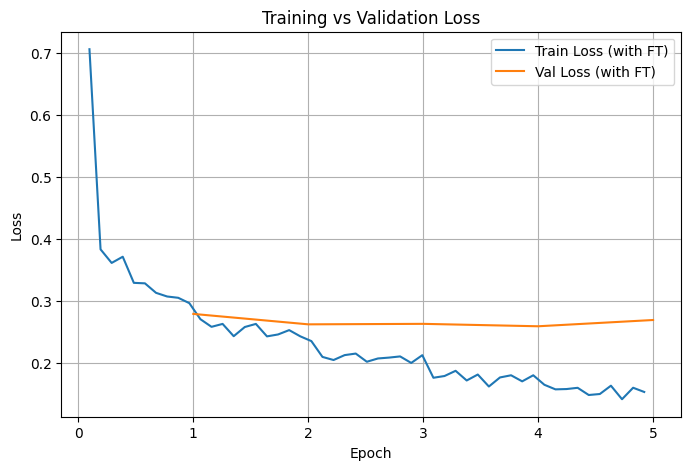

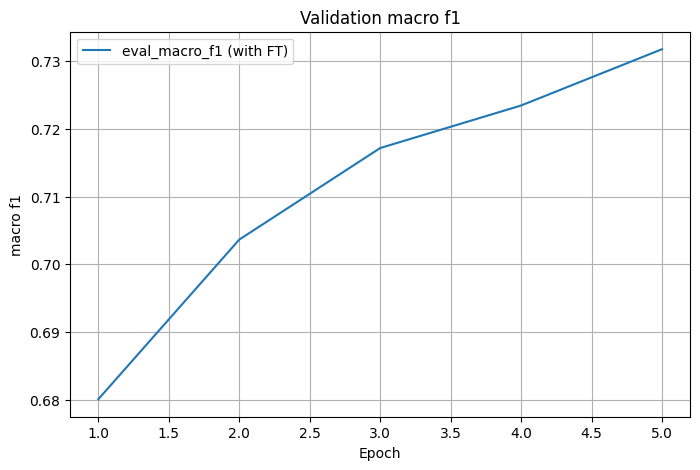

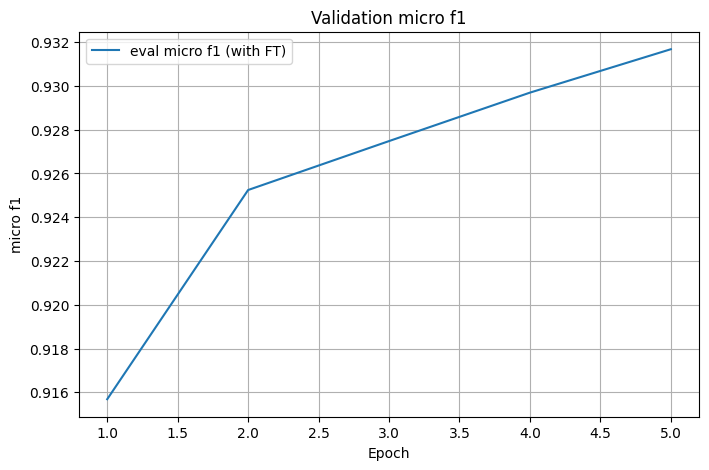

In [ ]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()][["epoch", "loss"]]
val_loss   = df[df["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8,5))

plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss (with FT)")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Val Loss (with FT)")



plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

metrics = df[df["eval_accuracy"].notna()][
    ["epoch", "eval_accuracy", "eval_micro_f1", "eval_macro_f1"]
]

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_macro_f1"], label="eval_macro_f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("macro f1")
plt.title("Validation macro f1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_micro_f1"], label="eval micro f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("micro f1")
plt.title("Validation micro f1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# trainer.save_model("/content/drive/MyDrive/arabert_weighted")
from transformers import AutoModelForTokenClassification, AutoTokenizer

path = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL"

model.save_pretrained(path)
tokenizer.save_pretrained(path)

('/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL/tokenizer_config.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL/special_tokens_map.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL/vocab.txt',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL/added_tokens.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL/tokenizer.json')

In [ ]:
from datasets import load_dataset

dataset_name = "Ahmed-Selem/Shifaa_Arabic_Medical_Consultations"

try:
    dataset = load_dataset(dataset_name)
    # print(f"Successfully downloaded dataset: {dataset_name}")
    print(dataset)
except Exception as e:
    print(f"Error downloading dataset {dataset_name}: {e}")

import pandas as pd

df = dataset['train'].to_pandas()
# print("Dataset converted to pandas DataFrame. Displaying the first 5 rows:")
# display(df.head())

df['Main Category'] = df['Hierarchical Diagnosis'].apply(lambda x: x.split(' - ')[0] if isinstance(x, str) and ' - ' in x else x)
Physical_med_ds = df[
    df["Main Category"] =="الصحة البدنية"
]

print("Number of Physical medicine samples:", len(Physical_med_ds))
display(Physical_med_ds.head())

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['Question Title', 'Question', 'Answer', 'Doctor Name', 'Consultation Number', 'Date of Answer', 'Hierarchical Diagnosis'],
        num_rows: 84422
    })
})
Number of Physical medicine samples: 5321


,Question Title,Question,Answer,Doctor Name,Consultation Number,Date of Answer,Hierarchical Diagnosis,Main Category
70145,أشكو من فقدان الاتزان والدوخة، فما الأسباب وال...,السلام عليكم ورحمة الله وبركاته\n\nأنا شاب وزن...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ عبد العزي...,د. عطية إبراهيم محمد,2538398,2024-05-07,الصحة البدنية - أخرى,الصحة البدنية
70146,ممارسة العادة السرية هل تؤدي إلى استنزاف المخز...,السلام عليكم ورحمة الله وبركاته\n\nهل الأعراض ...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ علي حفظه ...,د. محمد عبد العليم,2297495,2024-02-19,الصحة البدنية - أخرى,الصحة البدنية
70147,هل القفز إلى الماء عند السباحة يسبب أضرارًا من...,السلام عليكم ورحمة الله وبركاته\nأشكركم على هذ...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ زيد حفظه ...,د. عطية إبراهيم محمد,2506200,2023-05-29,الصحة البدنية - أخرى,الصحة البدنية
70148,عملية تحويل المعدة وتأثيرها في علاج السمنة وال...,السلام عليكم ورحمة الله وبركاته.\n\nأنا آنسة، ...,بسم الله الرحمن الرحيم\nالأخت الفاضلة/ م.ح.م ح...,د. محمد حمودة,2101041,2023-04-17,الصحة البدنية - أخرى,الصحة البدنية
70149,ما هي العوامل التي تساعدني كي أصبح شجاعاً وأدا...,السلام عليكم.\n\nأنا لدي مشكلة منذ صغري تضايقن...,بسم الله الرحمن الرحيم\nالأخ الفاضل/ خالد حفظه...,د. مأمون مبيض,2498559,2022-12-01,الصحة البدنية - أخرى,الصحة البدنية


In [ ]:
encoded_rows = Physical_med_ds.apply(encoding_word_medcine, axis=1)

X = encoded_rows.apply(lambda x: x["word"]).tolist()
Y = encoded_rows.apply(lambda x: x["label_id"]).tolist()
encoded_data =[]
for sent, lab in zip(X, Y):
    encoded_data.append(encode_sentence(sent, lab, max_len=128))


In [ ]:
train_data, val_data = train_test_split(
    encoded_data,
    test_size=0.1,
    random_state=42
)
train_dataset = PunctuationDataset(train_data)
val_dataset   = PunctuationDataset(val_data)

In [ ]:
trainer.train_dataset = train_dataset
trainer.eval_dataset = val_dataset
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Micro F1,Macro F1
1,0.272100,0.248796,0.917419,0.917419,0.676069
2,0.215700,0.237895,0.924574,0.924574,0.702640
3,0.167000,0.236055,0.929963,0.929963,0.728073
4,0.133000,0.239781,0.933889,0.933889,0.752543
5,0.110600,0.248745,0.937315,0.937315,0.766985


TrainOutput(global_step=2995, training_loss=0.18488590036688343, metrics={'train_runtime': 550.9919, 'train_samples_per_second': 43.449, 'train_steps_per_second': 5.436, 'total_flos': 1563931782927360.0, 'train_loss': 0.18488590036688343, 'epoch': 5.0})

In [ ]:
preds = trainer.predict(val_dataset)
compute_metrics(preds)

{'accuracy': 0.937314870989615,
 'micro_f1': 0.937314870989615,
 'macro_f1': 0.7669845974123637}

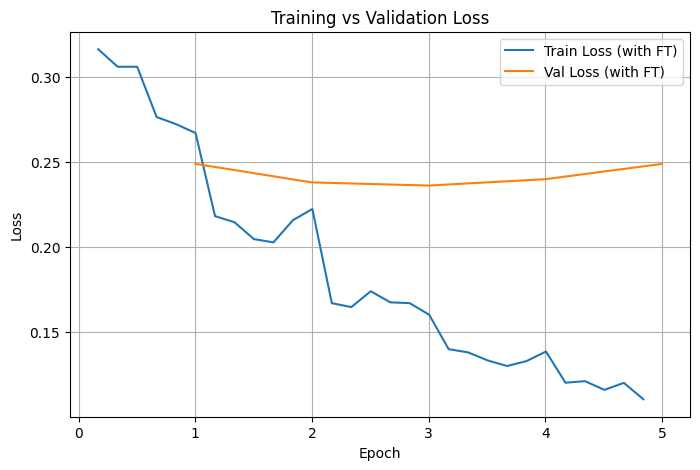

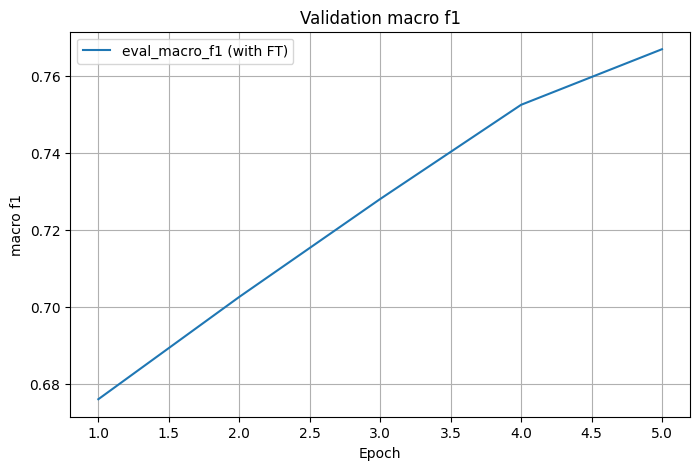

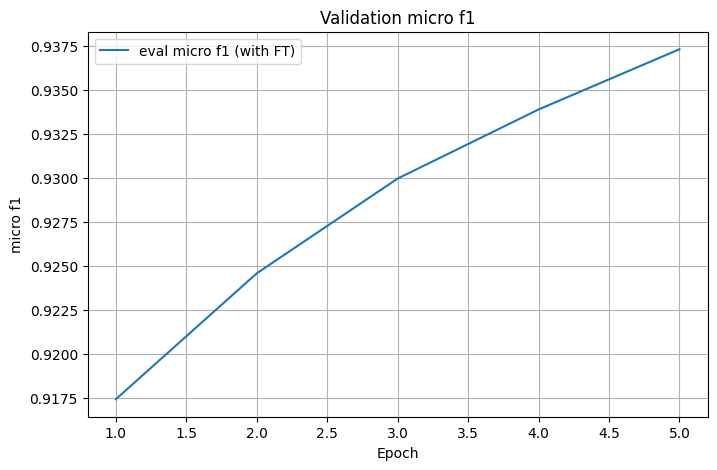

In [ ]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()][["epoch", "loss"]]
val_loss   = df[df["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(8,5))

plt.plot(train_loss["epoch"], train_loss["loss"], label="Train Loss (with FT)")
plt.plot(val_loss["epoch"], val_loss["eval_loss"], label="Val Loss (with FT)")



plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

metrics = df[df["eval_accuracy"].notna()][
    ["epoch", "eval_accuracy", "eval_micro_f1", "eval_macro_f1"]
]

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_macro_f1"], label="eval_macro_f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("macro f1")
plt.title("Validation macro f1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(metrics["epoch"], metrics["eval_micro_f1"], label="eval micro f1 (with FT)")

plt.xlabel("Epoch")
plt.ylabel("micro f1")
plt.title("Validation micro f1")
plt.legend()
plt.grid(True)
plt.show()

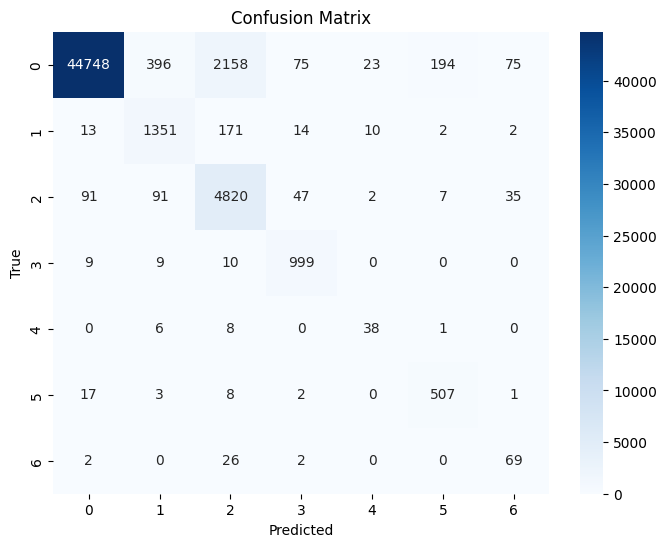

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
labels, preds = get_predictions(model, val_dataset, device)
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer

path = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2"

model.save_pretrained(path)
tokenizer.save_pretrained(path)

('/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2/tokenizer_config.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2/special_tokens_map.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2/vocab.txt',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2/added_tokens.json',
 '/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2/tokenizer.json')

In [ ]:

araBERT_ft_wl_MedData = {
    "number_step": 9,
    "name_model": "Fine-tuning with WL",
    "features": "Contextual subword embeddings",
    "parameters_model": "Fine-tuning + class weights",
    "methods_preprocessing": "tokenization + padding",
    "accuracy": 0.937,
    "F-score-macro": 0.766,
    "F-score-micro": 0.937
}
dictionary.append(araBERT_ft_wl_MedData)

In [ ]:
dictionary


[{'number_step': 1,
  'name_model': 'LSTM',
  'features': 'Word embeddings',
  'parameters_model': 'default',
  'methods_preprocessing': 'tokenization + padding',
  'accuracy': 0.17,
  'F-score-macro': 0.106,
  'F-score-micro': 0.167},
 {'number_step': 1,
  'name_model': 'BiLSTM',
  'features': 'Word embeddings',
  'parameters_model': 'default',
  'methods_preprocessing': 'tokenization + padding',
  'accuracy': 0.6,
  'F-score-macro': 0.266,
  'F-score-micro': 0.598},
 {'number_step': 3,
  'name_model': 'BiLSTM_weight',
  'features': 'Word embeddings',
  'parameters_model': 'class weights',
  'methods_preprocessing': 'tokenization + padding',
  'accuracy': 0.951,
  'F-score-macro': 0.412,
  'F-score-micro': 0.943},
 {'number_step': 4,
  'name_model': 'word2vec_CBOW',
  'features': 'pretrain embeddings',
  'parameters_model': 'class weights',
  'methods_preprocessing': 'tokenization + padding',
  'accuracy': 0.927,
  'F-score-macro': 0.927,
  'F-score-micro': None},
 {'number_step': 5,


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import gdown
import re
import os
def encoding_word(texts):
  words_without_puncts = []
  leabels = []
  l_id=[]
  punct = {'.':1,'،':2,'؟':3,'!':4,':':5,'؛':6,' ':0}
  words = texts.split()
  for word in words:
    match = re.match(r"(.*?)([،\.\؟\!\:\؛])?$", word)
    clean = match.group(1)
    puncts_in_phrase = match.group(2) or " "
    words_without_puncts.append(clean)
    leabels.append(puncts_in_phrase)
    # print(leabels)
  l_id=[punct[p] for p in leabels]
  # df = pd.DataFrame({
  # "word": words_without_puncts,
  # "punct": leabels,
  # "label_id": l_id
  # })
  return words_without_puncts,l_id


# def adapt_input(data):
#     if isinstance(data, pd.DataFrame):
#         return data

#     if isinstance(data, str):
#         return encoding_word(data)

#     raise TypeError("Input must be DataFrame or raw text")

def sequence(words, labels, max_len=128):
    X, Y = [], []
    for i in range(0, len(words), max_len):
        X.append(words[i:i+max_len])
        Y.append(labels[i:i+max_len])
    return X, Y

def encode_sentence(words, labels, tokenizer,max_len=128):
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt"
    )

    word_ids = encoding.word_ids()
    label_ids = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            label_ids.append(-100)
        elif word_idx != previous_word_idx:
            label_ids.append(labels[word_idx])
        else:
            label_ids.append(-100)
        previous_word_idx = word_idx

    encoding["labels"] = torch.tensor(label_ids)
    return encoding

class PunctuationDataset(torch.utils.data.Dataset):
  def __init__(self, data):
      self.data = data

  def __len__(self):
      return len(self.data)

  def __getitem__(self, idx):
      return {k: v.squeeze(0) for k, v in self.data[idx].items()}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def evaluate_best_model(test_dataset_url, model_path):
    texts = []
    if test_dataset_url.startswith("http"):
        local_dir = "/tmp/test_data"
        gdown.download_folder(
            test_dataset_url,
            output=local_dir,
            quiet=True,
            use_cookies=False
        )
        test_dataset_url = local_dir
    if os.path.isdir(test_dataset_url):
        for file in sorted(os.listdir(test_dataset_url)):
            if file.endswith(".txt"):
                file_path = os.path.join(test_dataset_url, file)
                with open(file_path, "r", encoding="utf-8") as f:
                    texts.append(f.read())
    elif os.path.isfile(test_dataset_url):
        with open(test_dataset_url, "r", encoding="utf-8") as f:
            texts.append(f.read())

    else:
        raise ValueError("Invalid dataset path or URL")

    text = "\n\n".join(texts)
    X,Y = encoding_word(text)
    # X = df["word"].tolist()
    # Y = df["label_id"].tolist()
    X,Y=sequence(X,Y)

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForTokenClassification.from_pretrained(model_path)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()


    test_encoded_data = []
    for sent, lab in zip(X, Y):
      test_encoded_data.append(encode_sentence(sent, lab,tokenizer, max_len=128))

    test_dataset = PunctuationDataset(test_encoded_data)



    all_preds = []
    all_labels = []

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=4,
        shuffle=False
    )

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            predictions = torch.argmax(outputs.logits, dim=-1)

            preds = predictions.cpu().numpy()
            true_labels = labels.cpu().numpy()

            for p, t in zip(preds, true_labels):
                for pred_label, true_label in zip(p, t):
                    if true_label != -100:
                        all_preds.append(pred_label)
                        all_labels.append(true_label)

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    f1_micro = f1_score(all_labels, all_preds, average="micro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    print(" نتائج التقييم:")
    print(f"Accuracy = {accuracy:.4f}")
    print(f"F1-score-macro = {f1:.4f}")
    print(f"F1-score-micro = {f1_micro:.4f}")
    print(f"F1-score-weighted = {f1_weighted:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))


    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()
    return f1

 نتائج التقييم:
Accuracy = 0.8559
F1-score-macro = 0.4275
F1-score-micro = 0.8559
F1-score-weighted = 0.8575

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95    128655
           1       0.63      0.15      0.24     11304
           2       0.29      0.67      0.40      8406
           3       0.52      0.55      0.53       343
           4       0.07      0.06      0.06       280
           5       0.48      0.60      0.53      1858
           6       0.21      0.41      0.27       317

    accuracy                           0.86    151163
   macro avg       0.45      0.48      0.43    151163
weighted avg       0.89      0.86      0.86    151163



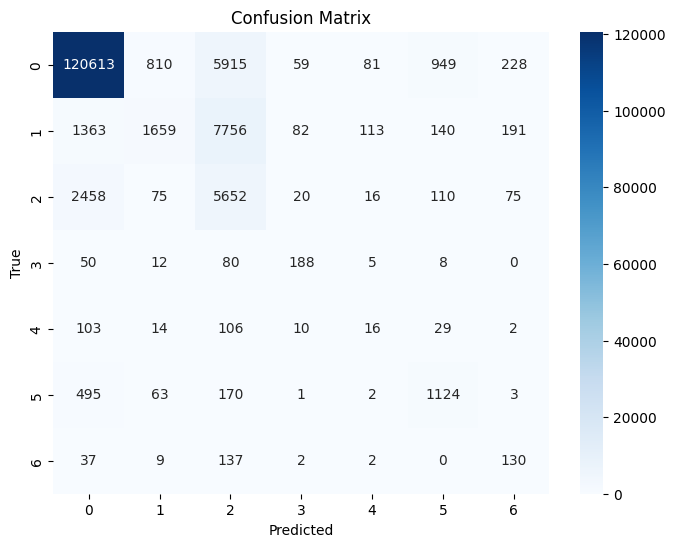

0.4274679142373263

In [ ]:
# BEST_MODEL_PATH = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss"
BEST_MODEL_PATH = "/content/drive/MyDrive/arabert_finetuned_model_wieghtedLoss_MEDICAL_2"
Test_data = "/content/drive/MyDrive/ABC/ABC"
#https://drive.google.com/drive/folders/1QUtrSPhvsRZtdcjbe8uv-oOToLWiVOjy?usp=drive_link
evaluate_best_model(Test_data, BEST_MODEL_PATH)